## Phase 2: Generalize Linear Probes across Multiple Datasets: Phi-3-mini-4k-instruct

* Train probes on [D1,D2,D3,D4]'s Acc/binarized SE, and test on D5's Acc; upper-bound should be training and testing on D5's Acc;
* Train probes on D1's Acc/binarized SE, and test on [D2,D3,D4,D5]'s Acc.


In [1]:
%load_ext autoreload
%autoreload 2

import os
import pickle
import yaml
import json

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import torch

from copy import deepcopy
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression

import wandb

d1_path = '/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240506_175221-nvg0zwqr/files'  # path for mistral-7b on trivia_qa (2k)
d2_path = '/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240506_040906-y4ozhtoh/files'  # path for mistral-7b on nq (2k)
d3_path = '/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240506_230521-8lk97z8n/files'  # path for mistral-7b on squad (2k)
d4_path = '/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240507_083131-r4g2el2d/files'  # path for mistral-7b on bioasq (2k)
d5_path = '/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240507_052402-gutqs8nf/files'  # path for mistral-7b on svamp (1k)

Matplotlib created a temporary cache directory at /tmp/matplotlib-6wvj_86a because the default path (/scratch-ssd/oatml/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## Data Preparation

In [2]:
# Utility functions
def binarize_entropy(entropy, thres=0.0):  # 0.0 means even splits for normalized entropy scores
    """Binarize entropy scores into 0's and 1's"""
    binary_entropy = torch.full_like(entropy, -1, dtype=torch.float)
    binary_entropy[entropy < thres] = 0
    binary_entropy[entropy > thres] = 1

    return binary_entropy

def load_dataset(path, n_sample=1000000000):
    os.chdir(path)  # path for mistral-7b on dataset
    
    # Read validation generated embeddings
    f = open('validation_generations.pkl', 'rb')
    generations = pickle.load(f)
    f.close()
    
    # Read uncertainty measures (p-true, predictive/semantic uncertainties)
    g = open('uncertainty_measures.pkl', 'rb')
    measures = pickle.load(g)
    g.close()
    
    entropy = torch.tensor(measures['uncertainty_measures']['cluster_assignment_entropy']).to(torch.float32) 
    ca_entropy = entropy.clone()
    ca_entropy = (ca_entropy - ca_entropy.mean()) / ca_entropy.std()
    
    accuracies = torch.tensor([record['most_likely_answer']['accuracy'] for record in generations.values()])
    
    # TBG
    tbg_dataset = torch.stack([record['most_likely_answer']['emb_last_tok_before_gen'] 
                                       for record in generations.values()]).squeeze(-2).transpose(0, 1).to(torch.float32)
    # SLT
    slt_dataset = torch.stack([record['most_likely_answer']['emb_tok_before_eos'] 
                                       for record in generations.values()]).squeeze(-2).transpose(0, 1).to(torch.float32)

    return (tbg_dataset[:,:n_sample,:], 
            slt_dataset[:,:n_sample,:], 
            entropy[:n_sample], 
            ca_entropy[:n_sample], 
            accuracies[:n_sample])

In [3]:
class Dataset:
    def __init__(self, values):
        self.tbg_dataset = values[0]
        self.slt_dataset = values[1]
        self.entropy = values[2]
        self.ca_entropy = values[3]
        self.accuracies = values[4]

In [4]:
D1 = Dataset(load_dataset(d1_path))
D2 = Dataset(load_dataset(d2_path))
D3 = Dataset(load_dataset(d3_path))
D4 = Dataset(load_dataset(d4_path))
D5 = Dataset(load_dataset(d5_path))

In [5]:
Ds = [D1, D2, D3, D4, D5]  # all datasets

In [6]:
D1.name = 'trivia_qa'
D2.name = 'nq'
D3.name = 'squad'
D4.name = 'bioasq'
D5.name = 'svamp'

# Set total size for splits
for D in Ds:
    D.total_size = D.entropy.shape[0]

In [7]:
for i, D in enumerate(Ds):
    D.other_ids = [j for j in range(len(Ds)) if j != i]
    D.other_names = [Ds[j].name for j in D.other_ids]

## Test Acc/SE -> Acc/SE individually (and plot together)

### Helper methods

In [8]:
# Train/val/test splits for sklearn lr
from sklearn.model_selection import train_test_split

def create_Xs_and_ys(tok_bef_gen_layered_datasets, ca_entropy, total_size, val_test_splits=[0.2, 0.1]):
    # Data splitting for sklearn linear models
    X = tok_bef_gen_layered_datasets.numpy()
    y = ca_entropy.numpy()

    valid_size = val_test_splits[0]
    test_size = val_test_splits[1]

    X_trains = []
    X_vals = []
    X_tests = []
    y_trains = []
    y_vals = []
    y_tests = []

    for i in range(X.shape[0]):
        # Split data into train, validation, and test sets
        X_train_val, X_test, y_train_val, y_test = train_test_split(X[i], y, test_size=test_size, random_state=42)
        X_tests.append(X_test)
        y_tests.append(y_test)
        X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=valid_size, random_state=42) 
        X_trains.append(X_train)
        y_trains.append(y_train)
        X_vals.append(X_val)
        y_vals.append(y_val)

    return X_trains, X_vals, X_tests, y_trains, y_vals, y_tests

In [9]:
# Training and testing helper function.
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss, roc_auc_score, mean_squared_error

# Use verbose=1 for model loss tracking.
def sklearn_train_and_evaluate(model, X_train, y_train, X_valid, y_valid, binary_cls=False, title="", silent=False):
    model.fit(X_train, y_train)
    
    # Calculate training loss and score
    if binary_cls:
        train_probs = model.predict_proba(X_train)
        train_loss = log_loss(y_train, train_probs)
    else:
        train_preds = model.predict(X_train)
        train_loss = mean_squared_error(y_train, train_preds)

    # Calculate validation loss
    valid_preds = model.predict(X_valid)
    if binary_cls:
        valid_probs = model.predict_proba(X_valid)
        valid_loss = log_loss(y_valid, valid_probs)
        val_accuracy = np.mean((valid_preds == y_valid).astype(int))
        auroc_score = roc_auc_score(y_valid, valid_probs[:,1])
        if not silent:
            print(f"Validation Accuracy: {val_accuracy:.4f}, AUROC: {auroc_score:.4f}")
    else:
        valid_loss = mean_squared_error(y_valid, valid_preds)

    if not silent:
        print(f"Training Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}")

def sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=False, silent=False):
    test_preds = model.predict(X_test)
    if binary_cls:
        test_probs = model.predict_proba(X_test)
        test_loss = log_loss(y_test, test_probs)
    else:
        test_loss = mean_squared_error(y_test, test_preds)
        
    if binary_cls:
        test_probs = test_probs[:, 1]  # Probabilities for the positive class
        test_accuracy = np.mean((test_preds == y_test).astype(int))
        auroc_score = roc_auc_score(y_test, test_probs)
        if not silent:
            print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, AUROC: {auroc_score:.4f}")
        return test_loss, test_accuracy, auroc_score
    else:
        test_score = model.score(X_test, y_test)
        if not silent:
            print(f"Test Loss: {test_loss:.4f}, Test R-squared: {test_score:.4f}")
        return test_loss

In [10]:
# Plotting methods
from datetime import datetime

def plot_metrics(test_metrics_list, model_names, metric_name="MSE Losses", save_fig=False, use_logarithm=False, preset_layer_indices=None, legend_outside=False):
    plt.figure(figsize=(10, 5))
    
    # Make sure that model_names array and test_metrics_list have the same length.
    if len(test_metrics_list) != len(model_names):
        raise ValueError("The length of test_metrics_list and model_names must be the same.")
    
    for test_metrics, model_name in zip(test_metrics_list, model_names):
        test_metrics = torch.tensor(test_metrics, dtype=torch.float32)
        if use_logarithm:
            test_metrics = torch.log(test_metrics + 1e-6)
        if preset_layer_indices is not None:
            layer_indices = preset_layer_indices
        else:
            layer_indices = torch.arange(len(test_metrics)) + 1  # +1 if layer indexing starts at 1
        plt.plot(layer_indices, test_metrics, marker='o', linestyle='-', label=model_name)
    
    plt.title(f'Test {metric_name}')
    plt.xlabel('Layer')
    plt.ylabel(f'{metric_name}')
    plt.xticks(layer_indices) 
    if legend_outside:
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    else:
        plt.legend()
    plt.grid(True)
    formatted_time = datetime.now().strftime("%Y%m%d-%H%M%S")
    full_path = '~/Downloads/oatml/semantic_uncertainty/figures'
    full_path = os.path.expanduser(full_path)
    if save_fig:
        plt.savefig(f'{full_path}/{formatted_time}_test_{metric_name}_for_{"_".join(model_names)}.jpg')
    plt.show()

def plot_metrics_w_constant(prev_best, topk_test_aucs: dict, token='TBG'):
    """
    Plots the test AUROC scores for top-k inputs alongside a horizontal line indicating
    the previous best score.
    """
    topk_test_aucs_scores = list(topk_test_aucs.values())
    x_labels = ['layer ' + ','.join(map(str, key)) for key in topk_test_aucs.keys()]
    
    # Set up the plot
    plt.figure(figsize=(10, 5)) 
    plt.plot(x_labels, topk_test_aucs_scores, label='Test AUROC for top-k Inputs', marker='o', linestyle='-')
    
    # Plot the previous best score as a horizontal line
    plt.axhline(y=prev_best, color='r', linestyle='--', label='Previous Best Test AUROC')
    
    # Adding labels and title
    plt.xlabel('Top-k Best Layers')  # Label for the X-axis
    plt.ylabel('AUROC Score')  # Label for the Y-axis
    plt.title(f'AUROC Scores for Linear Probes Trained on Concatenated Inputs from {token}') 
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.legend()  # Add a legend to identify the lines
    
    plt.grid(True)
    
    # Display the plot
    plt.tight_layout()
    plt.show()

In [11]:
# Best split for SE binarization.
def best_split(entropy: torch.Tensor, label="Dx"):
    ents = entropy.numpy()
    splits = np.linspace(1e-10, ents.max(), 100)
    split_mses = []
    for split in splits:
        low_idxs, high_idxs = ents < split, ents >= split
    
        low_mean = np.mean(ents[low_idxs])
        high_mean = np.mean(ents[high_idxs])
    
        mse = np.sum((ents[low_idxs] - low_mean)**2) + np.sum((ents[high_idxs] - high_mean)**2)
        mse = np.sum(mse)
    
        split_mses.append(mse)
    
    split_mses = np.array(split_mses)
    
    plt.plot(splits, split_mses, label=label)
    return splits[np.argmin(split_mses)]

def binarize_entropy(entropy, thres=0.0):  # 0.0 means even splits for normalized entropy scores
    """Binarize entropy scores into 0's and 1's"""
    binary_entropy = torch.full_like(entropy, -1, dtype=torch.float)
    binary_entropy[entropy < thres] = 0
    binary_entropy[entropy > thres] = 1

    return binary_entropy

In [12]:
def best_metric(metrics_list, token="TBG", train="Binarized SE", test="Binarized SE", ds=[["train_ds", "test_ds"]], topk=5):
    for i, metrics in enumerate(metrics_list):
        sorted_metrics = np.sort(metrics)[::-1]
        indices = np.argsort(metrics)[::-1]
        print(f"{token}: max AUROC for LR trained on {ds[i][0]}'s {train} and tested on {ds[i][1]}'s {test}:\n\t" 
              + "\n\t".join([f"- {sorted_metrics[k]:.4f} at layer {indices[k]+1}" for k in range(topk)]))

### Binarize Semantic Entropy (SE)

Dummy accuracy for trivia_qa: 0.5125
Dummy accuracy for nq: 0.6210
Dummy accuracy for squad: 0.6975
Dummy accuracy for bioasq: 0.5135
Dummy accuracy for svamp: 0.7890


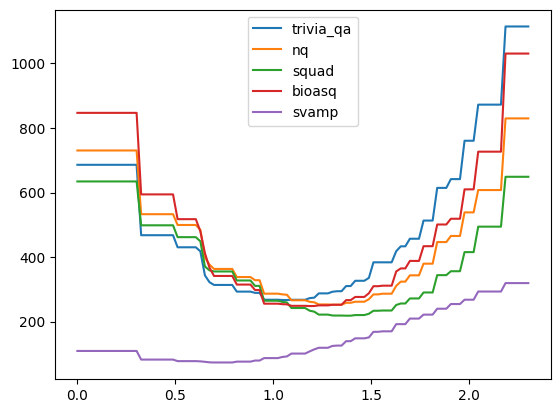

In [13]:
# Binarize SE by best split
for D in Ds:
    split = best_split(D.entropy, D.name)
    plt.legend()
    D.b_entropy = binarize_entropy(D.entropy, split)
    print(f"Dummy accuracy for {D.name}: {max(torch.mean(D.b_entropy).item(), 1-torch.mean(D.b_entropy).item()):.4f}")

### Use linear probes to predict Binarized SE

In [21]:
for D in Ds:
    
    # TBG
    X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(D.tbg_dataset, D.b_entropy, D.total_size)
    tb_accs = []
    tb_aucs = []
    tb_models = []
    
    for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
        print(f"Training on {D.name}-TBG {i+1}/{len(X_trains)}")
        model = LogisticRegression()
        sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {D.name}-TBG {i+1} layer")
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
        tb_accs.append(test_acc)
        tb_aucs.append(test_auc)
        tb_models.append(model)

    D.tb_accs = tb_accs
    D.tb_aucs = tb_aucs
    D.tb_models = tb_models

    # SLT
    X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(D.slt_dataset, D.b_entropy, D.total_size)
    sb_accs = []
    sb_aucs = []
    sb_models = []
    
    for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
        print(f"Training on {D.name}-SLT {i+1}/{len(X_trains)}")
        model = LogisticRegression()
        sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {D.name}-SLT {i+1} layer")
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
        sb_accs.append(test_acc)
        sb_aucs.append(test_auc)
        sb_models.append(model)

    D.sb_accs = sb_accs
    D.sb_aucs = sb_aucs
    D.sb_models = sb_models
    
    plot_metrics([tb_aucs, sb_aucs], ['TBG Binarized SE', 'SLT Binarized SE'], f'AUROC on {D.name}')

Training on trivia_qa-TBG 1/33
Validation Accuracy: 0.5889, AUROC: 0.6325
Training Loss: 0.4905, Validation Loss: 0.6685
Test Loss: 0.6851, Test Accuracy: 0.5900, AUROC: 0.6262
Training on trivia_qa-TBG 2/33
Validation Accuracy: 0.5972, AUROC: 0.6636
Training Loss: 0.4377, Validation Loss: 0.6682
Test Loss: 0.6813, Test Accuracy: 0.5950, AUROC: 0.6650
Training on trivia_qa-TBG 3/33
Validation Accuracy: 0.6139, AUROC: 0.6925
Training Loss: 0.3549, Validation Loss: 0.6673
Test Loss: 0.6464, Test Accuracy: 0.6750, AUROC: 0.7194
Training on trivia_qa-TBG 4/33
Validation Accuracy: 0.6472, AUROC: 0.7244
Training Loss: 0.3081, Validation Loss: 0.6589
Test Loss: 0.6698, Test Accuracy: 0.6600, AUROC: 0.7230
Training on trivia_qa-TBG 5/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6750, AUROC: 0.7401
Training Loss: 0.2560, Validation Loss: 0.6690
Test Loss: 0.6771, Test Accuracy: 0.6850, AUROC: 0.7315
Training on trivia_qa-TBG 6/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6944, AUROC: 0.7437
Training Loss: 0.2174, Validation Loss: 0.6848
Test Loss: 0.7278, Test Accuracy: 0.6750, AUROC: 0.7259
Training on trivia_qa-TBG 7/33


...

Validation Accuracy: 0.8111, AUROC: 0.8575
Training Loss: 0.0031, Validation Loss: 0.7355
Test Loss: 0.8536, Test Accuracy: 0.8000, AUROC: 0.8298
Training on svamp-TBG 24/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8056, AUROC: 0.8471
Training Loss: 0.0027, Validation Loss: 0.7614
Test Loss: 0.9884, Test Accuracy: 0.7700, AUROC: 0.8096
Training on svamp-TBG 25/33
Validation Accuracy: 0.8000, AUROC: 0.8561
Training Loss: 0.0022, Validation Loss: 0.7574
Test Loss: 0.9332, Test Accuracy: 0.7700, AUROC: 0.8161
Training on svamp-TBG 26/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7889, AUROC: 0.8404
Training Loss: 0.0016, Validation Loss: 0.9315
Test Loss: 1.1127, Test Accuracy: 0.7700, AUROC: 0.8129
Training on svamp-TBG 27/33
Validation Accuracy: 0.7944, AUROC: 0.8416
Training Loss: 0.0012, Validation Loss: 0.8587
Test Loss: 1.2660, Test Accuracy: 0.7700, AUROC: 0.7947
Training on svamp-TBG 28/33
Validation Accuracy: 0.8222, AUROC: 0.8555
Training Loss: 0.0010, Validation Loss: 0.8093
Test Loss: 1.4418, Test Accuracy: 0.7500, AUROC: 0.7843
Training on svamp-TBG 29/33
Validation Accuracy: 0.8333, AUROC: 0.8729
Training Loss: 0.0007, Validation Loss: 0.7422
Test Loss: 1.0430, Test Accuracy: 0.7600, AUROC: 0.8155
Training on svamp-TBG 30/33
Validation Accuracy: 0.8389, AUROC: 0.8823
Training Loss: 0.0006, Validation Loss: 0.7321
Test Loss: 0.8938, Test Accuracy: 0.8200, AUROC: 0.8635
Training on svamp-TBG 31/33
Validation Accuracy: 0.8389, AUROC: 0.8950
Training Loss: 0.0004, Validation Loss: 0.7121
Test Loss: 0.9213, Test Accuracy: 0.8500

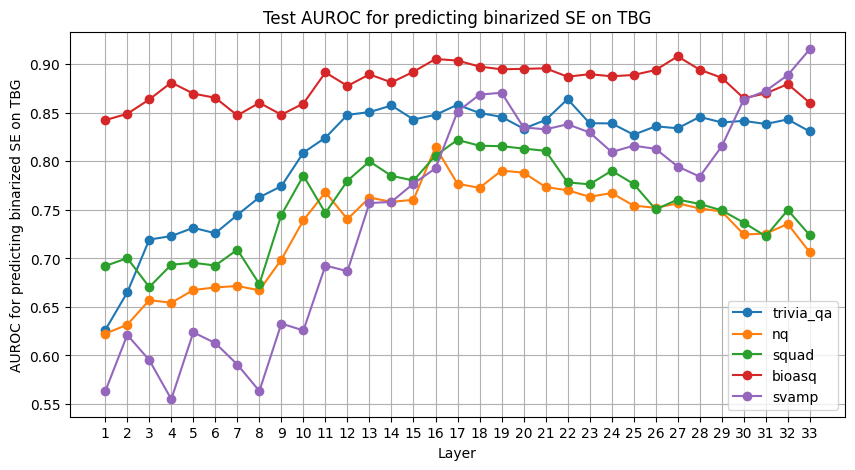

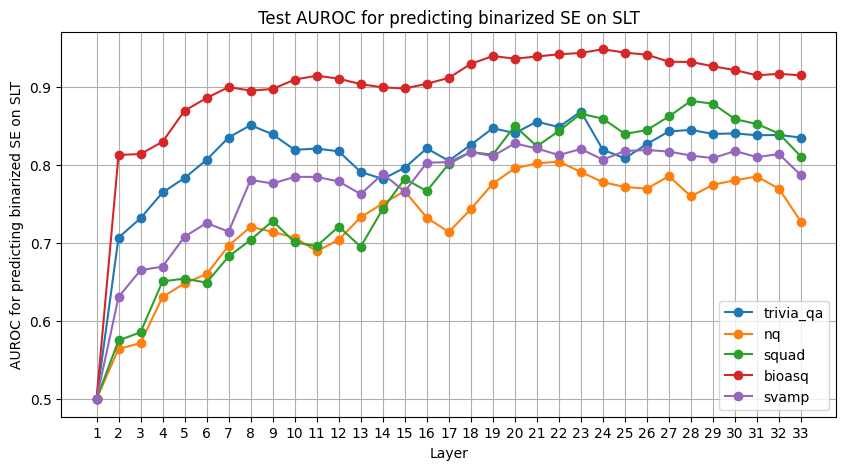

In [15]:
# Plot test AUROC curves for all on predicting binarized SE
plot_metrics([D.tb_aucs for D in Ds], [f"{D.name}" for D in Ds], f'AUROC for predicting binarized SE on TBG')
plot_metrics([D.sb_aucs for D in Ds], [f"{D.name}" for D in Ds], f'AUROC for predicting binarized SE on SLT')

In [16]:
# Report best metrics
best_metric([D.tb_aucs for D in Ds], ds=[[D.name]*2 for D in Ds])
best_metric([D.sb_aucs for D in Ds], "SLT", ds=[[D.name]*2 for D in Ds])

TBG: max AUROC for LR trained on trivia_qa's Binarized SE and tested on trivia_qa's Binarized SE:
	- 0.8641 at layer 22
	- 0.8583 at layer 17
	- 0.8575 at layer 14
	- 0.8507 at layer 13
	- 0.8498 at layer 18
TBG: max AUROC for LR trained on nq's Binarized SE and tested on nq's Binarized SE:
	- 0.8148 at layer 16
	- 0.7905 at layer 19
	- 0.7884 at layer 20
	- 0.7768 at layer 17
	- 0.7736 at layer 21
TBG: max AUROC for LR trained on squad's Binarized SE and tested on squad's Binarized SE:
	- 0.8221 at layer 17
	- 0.8161 at layer 18
	- 0.8156 at layer 19
	- 0.8132 at layer 20
	- 0.8108 at layer 21
TBG: max AUROC for LR trained on bioasq's Binarized SE and tested on bioasq's Binarized SE:
	- 0.9082 at layer 27
	- 0.9054 at layer 16
	- 0.9038 at layer 17
	- 0.8976 at layer 18
	- 0.8958 at layer 21
TBG: max AUROC for LR trained on svamp's Binarized SE and tested on svamp's Binarized SE:
	- 0.9155 at layer 33
	- 0.8889 at layer 32
	- 0.8726 at layer 31
	- 0.8707 at layer 19
	- 0.8687 at layer

### Use linear probes to predict Accuracy

Training on trivia_qa-TBG 1/33
Validation Accuracy: 0.6028, AUROC: 0.6345
Training Loss: 0.5154, Validation Loss: 0.6599
Test Loss: 0.6787, Test Accuracy: 0.5800, AUROC: 0.6126
Training on trivia_qa-TBG 2/33
Validation Accuracy: 0.5944, AUROC: 0.6361
Training Loss: 0.4672, Validation Loss: 0.6642
Test Loss: 0.6750, Test Accuracy: 0.5850, AUROC: 0.6472
Training on trivia_qa-TBG 3/33
Validation Accuracy: 0.6111, AUROC: 0.6513
Training Loss: 0.3961, Validation Loss: 0.6866
Test Loss: 0.6811, Test Accuracy: 0.6200, AUROC: 0.6615
Training on trivia_qa-TBG 4/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6417, AUROC: 0.6812
Training Loss: 0.3526, Validation Loss: 0.6993
Test Loss: 0.6763, Test Accuracy: 0.6350, AUROC: 0.6884
Training on trivia_qa-TBG 5/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6667, AUROC: 0.6962
Training Loss: 0.3010, Validation Loss: 0.7307
Test Loss: 0.7930, Test Accuracy: 0.6500, AUROC: 0.6606
Training on trivia_qa-TBG 6/33


...

Validation Accuracy: 0.6806, AUROC: 0.7251
Training Loss: 0.0046, Validation Loss: 2.7034
Test Loss: 2.6847, Test Accuracy: 0.6500, AUROC: 0.7024
Training on trivia_qa-SLT 31/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6861, AUROC: 0.7257
Training Loss: 0.0046, Validation Loss: 2.5039
Test Loss: 2.4899, Test Accuracy: 0.6750, AUROC: 0.7062
Training on trivia_qa-SLT 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6944, AUROC: 0.7194
Training Loss: 0.0045, Validation Loss: 2.7029
Test Loss: 2.4063, Test Accuracy: 0.6900, AUROC: 0.7288
Training on trivia_qa-SLT 33/33
Validation Accuracy: 0.6667, AUROC: 0.7285
Training Loss: 0.0071, Validation Loss: 1.6530
Test Loss: 1.4809, Test Accuracy: 0.6600, AUROC: 0.7243


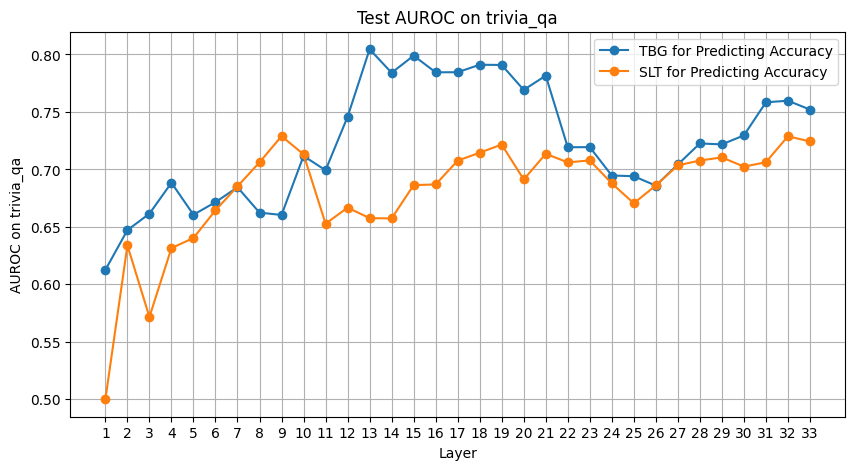

Training on nq-TBG 1/33
Validation Accuracy: 0.7389, AUROC: 0.5612
Training Loss: 0.4366, Validation Loss: 0.5774
Test Loss: 0.5950, Test Accuracy: 0.7100, AUROC: 0.5747
Training on nq-TBG 2/33
Validation Accuracy: 0.7389, AUROC: 0.5799
Training Loss: 0.3969, Validation Loss: 0.5845
Test Loss: 0.6102, Test Accuracy: 0.6850, AUROC: 0.5692
Training on nq-TBG 3/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7167, AUROC: 0.5756
Training Loss: 0.3322, Validation Loss: 0.6257
Test Loss: 0.6632, Test Accuracy: 0.6800, AUROC: 0.5432
Training on nq-TBG 4/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7028, AUROC: 0.5759
Training Loss: 0.2921, Validation Loss: 0.7615
Test Loss: 0.6914, Test Accuracy: 0.6700, AUROC: 0.5472
Training on nq-TBG 5/33


...

Validation Accuracy: 0.7028, AUROC: 0.7073
Training Loss: 0.0007, Validation Loss: 1.7611
Test Loss: 1.5307, Test Accuracy: 0.7450, AUROC: 0.7645
Training on nq-SLT 28/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7028, AUROC: 0.6809
Training Loss: 0.0005, Validation Loss: 1.8766
Test Loss: 1.5441, Test Accuracy: 0.7500, AUROC: 0.7551
Training on nq-SLT 29/33
Validation Accuracy: 0.7000, AUROC: 0.6939
Training Loss: 0.0004, Validation Loss: 1.9014
Test Loss: 1.5256, Test Accuracy: 0.7700, AUROC: 0.7567
Training on nq-SLT 30/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7278, AUROC: 0.6925
Training Loss: 0.0003, Validation Loss: 1.8805
Test Loss: 1.7010, Test Accuracy: 0.7600, AUROC: 0.7269
Training on nq-SLT 31/33
Validation Accuracy: 0.7389, AUROC: 0.7128
Training Loss: 0.0002, Validation Loss: 1.8608
Test Loss: 1.7873, Test Accuracy: 0.7400, AUROC: 0.7264
Training on nq-SLT 32/33
Validation Accuracy: 0.7222, AUROC: 0.7102
Training Loss: 0.0002, Validation Loss: 1.9669
Test Loss: 1.9996, Test Accuracy: 0.7200, AUROC: 0.7123
Training on nq-SLT 33/33
Validation Accuracy: 0.7194, AUROC: 0.6815
Training Loss: 0.0029, Validation Loss: 1.5443
Test Loss: 1.3868, Test Accuracy: 0.6750, AUROC: 0.6918


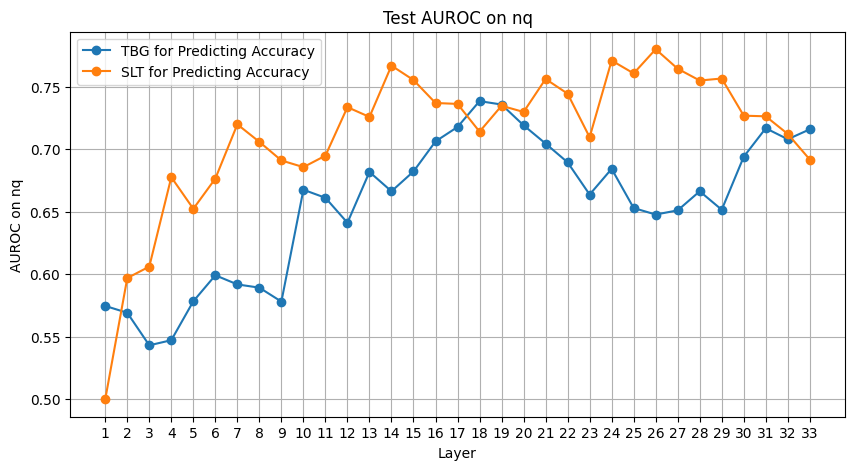

Training on squad-TBG 1/33
Validation Accuracy: 0.7778, AUROC: 0.6273
Training Loss: 0.4202, Validation Loss: 0.5080
Test Loss: 0.5606, Test Accuracy: 0.7600, AUROC: 0.6193
Training on squad-TBG 2/33
Validation Accuracy: 0.7750, AUROC: 0.6173
Training Loss: 0.3793, Validation Loss: 0.5173
Test Loss: 0.5633, Test Accuracy: 0.7650, AUROC: 0.6307
Training on squad-TBG 3/33
Validation Accuracy: 0.7694, AUROC: 0.6857
Training Loss: 0.3077, Validation Loss: 0.5014
Test Loss: 0.6334, Test Accuracy: 0.7550, AUROC: 0.5994
Training on squad-TBG 4/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7750, AUROC: 0.6762
Training Loss: 0.2648, Validation Loss: 0.5360
Test Loss: 0.6651, Test Accuracy: 0.7350, AUROC: 0.6262
Training on squad-TBG 5/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7583, AUROC: 0.6585
Training Loss: 0.2217, Validation Loss: 0.5830
Test Loss: 0.7255, Test Accuracy: 0.7350, AUROC: 0.5999
Training on squad-TBG 6/33


...

Validation Accuracy: 0.7583, AUROC: 0.6908
Training Loss: 0.0004, Validation Loss: 2.0526
Test Loss: 1.7577, Test Accuracy: 0.7600, AUROC: 0.7447
Training on squad-SLT 31/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7389, AUROC: 0.6907
Training Loss: 0.0004, Validation Loss: 2.0307
Test Loss: 1.5335, Test Accuracy: 0.8000, AUROC: 0.7777
Training on squad-SLT 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7722, AUROC: 0.6791
Training Loss: 0.0004, Validation Loss: 2.1317
Test Loss: 1.6717, Test Accuracy: 0.7650, AUROC: 0.7613
Training on squad-SLT 33/33
Validation Accuracy: 0.7333, AUROC: 0.6890
Training Loss: 0.0050, Validation Loss: 1.2514
Test Loss: 1.2200, Test Accuracy: 0.7450, AUROC: 0.7115


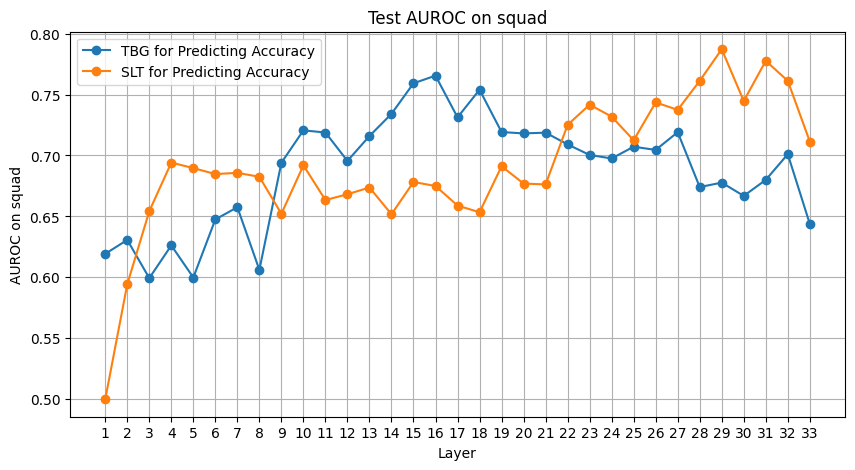

Training on bioasq-TBG 1/33
Validation Accuracy: 0.6944, AUROC: 0.7573
Training Loss: 0.4450, Validation Loss: 0.5727
Test Loss: 0.5238, Test Accuracy: 0.7400, AUROC: 0.7848
Training on bioasq-TBG 2/33
Validation Accuracy: 0.6944, AUROC: 0.7617
Training Loss: 0.4180, Validation Loss: 0.5831
Test Loss: 0.5320, Test Accuracy: 0.7500, AUROC: 0.7967
Training on bioasq-TBG 3/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7250, AUROC: 0.7644
Training Loss: 0.3397, Validation Loss: 0.6019
Test Loss: 0.5907, Test Accuracy: 0.7450, AUROC: 0.7733
Training on bioasq-TBG 4/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7139, AUROC: 0.7818
Training Loss: 0.3018, Validation Loss: 0.6123
Test Loss: 0.5969, Test Accuracy: 0.7250, AUROC: 0.7787
Training on bioasq-TBG 5/33


...

Validation Accuracy: 0.7167, AUROC: 0.7784
Training Loss: 0.0008, Validation Loss: 2.7479
Test Loss: 2.2818, Test Accuracy: 0.7500, AUROC: 0.8104
Training on bioasq-SLT 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7278, AUROC: 0.7821
Training Loss: 0.0007, Validation Loss: 2.5597
Test Loss: 2.4765, Test Accuracy: 0.7600, AUROC: 0.8052
Training on bioasq-SLT 33/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6889, AUROC: 0.7603
Training Loss: 0.0082, Validation Loss: 1.5899
Test Loss: 1.4681, Test Accuracy: 0.7450, AUROC: 0.7982


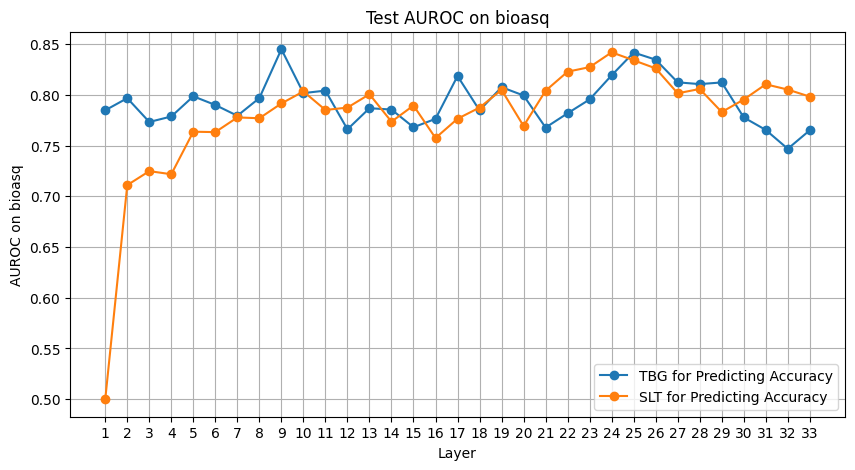

Training on svamp-TBG 1/33
Validation Accuracy: 0.5833, AUROC: 0.5575
Training Loss: 0.6566, Validation Loss: 0.6642
Test Loss: 0.6785, Test Accuracy: 0.6000, AUROC: 0.5800
Training on svamp-TBG 2/33
Validation Accuracy: 0.6556, AUROC: 0.6498
Training Loss: 0.6415, Validation Loss: 0.6291
Test Loss: 0.6889, Test Accuracy: 0.5800, AUROC: 0.5721
Training on svamp-TBG 3/33
Validation Accuracy: 0.6667, AUROC: 0.7055
Training Loss: 0.5772, Validation Loss: 0.5971
Test Loss: 0.6864, Test Accuracy: 0.5900, AUROC: 0.6198
Training on svamp-TBG 4/33
Validation Accuracy: 0.6611, AUROC: 0.6183
Training Loss: 0.5092, Validation Loss: 0.6843
Test Loss: 0.7497, Test Accuracy: 0.5900, AUROC: 0.6202
Training on svamp-TBG 5/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6611, AUROC: 0.6356
Training Loss: 0.4566, Validation Loss: 0.7012
Test Loss: 0.7553, Test Accuracy: 0.5600, AUROC: 0.6242
Training on svamp-TBG 6/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6944, AUROC: 0.6660
Training Loss: 0.3982, Validation Loss: 0.6855
Test Loss: 0.8146, Test Accuracy: 0.5700, AUROC: 0.5988
Training on svamp-TBG 7/33


...

Validation Accuracy: 0.7944, AUROC: 0.8544
Training Loss: 0.0053, Validation Loss: 1.0374
Test Loss: 1.0414, Test Accuracy: 0.7700, AUROC: 0.8493
Training on svamp-SLT 28/33
Validation Accuracy: 0.8000, AUROC: 0.8414
Training Loss: 0.0044, Validation Loss: 1.0427
Test Loss: 0.8312, Test Accuracy: 0.7600, AUROC: 0.8606
Training on svamp-SLT 29/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linea

Validation Accuracy: 0.7778, AUROC: 0.8231
Training Loss: 0.0039, Validation Loss: 1.2511
Test Loss: 1.0654, Test Accuracy: 0.7700, AUROC: 0.8489
Training on svamp-SLT 30/33
Validation Accuracy: 0.8167, AUROC: 0.8388
Training Loss: 0.0031, Validation Loss: 1.2361
Test Loss: 1.0561, Test Accuracy: 0.8100, AUROC: 0.8578
Training on svamp-SLT 31/33
Validation Accuracy: 0.7778, AUROC: 0.8554
Training Loss: 0.0019, Validation Loss: 1.0551
Test Loss: 0.9687, Test Accuracy: 0.8100, AUROC: 0.8646
Training on svamp-SLT 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linea

Validation Accuracy: 0.7722, AUROC: 0.8455
Training Loss: 0.0015, Validation Loss: 1.1160
Test Loss: 1.2122, Test Accuracy: 0.7800, AUROC: 0.8473
Training on svamp-SLT 33/33
Validation Accuracy: 0.7722, AUROC: 0.8271
Training Loss: 0.0098, Validation Loss: 0.8400
Test Loss: 0.9071, Test Accuracy: 0.7200, AUROC: 0.8222


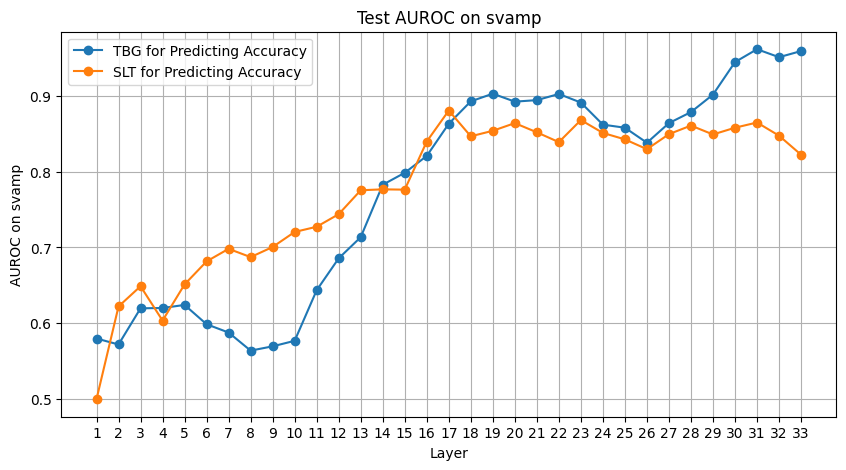

In [17]:
for D in Ds:
    
    # TBG
    X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(D.tbg_dataset, D.accuracies, D.total_size)
    ta_accs = []
    ta_aucs = []
    
    for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
        print(f"Training on {D.name}-TBG {i+1}/{len(X_trains)}")
        model = LogisticRegression()
        sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {D.name}-TBG {i+1} layer")
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
        ta_accs.append(test_acc)
        ta_aucs.append(test_auc)

    D.ta_accs = ta_accs
    D.ta_aucs = ta_aucs

    # SLT
    X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(D.slt_dataset, D.accuracies, D.total_size)
    sa_accs = []
    sa_aucs = []
    sa_models = []
    
    for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
        print(f"Training on {D.name}-SLT {i+1}/{len(X_trains)}")
        model = LogisticRegression()
        sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {D.name}-SLT {i+1} layer")
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
        sa_accs.append(test_acc)
        sa_aucs.append(test_auc)
        sa_models.append(model)

    D.sa_accs = sa_accs
    D.sa_aucs = sa_aucs
    D.sa_models = sa_models
    
    plot_metrics([ta_aucs, sa_aucs], ['TBG for Predicting Accuracy', 'SLT for Predicting Accuracy'], f'AUROC on {D.name}')

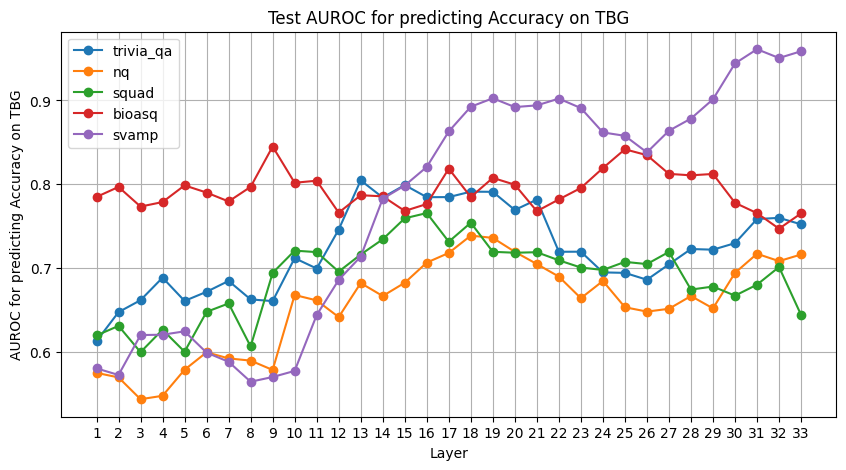

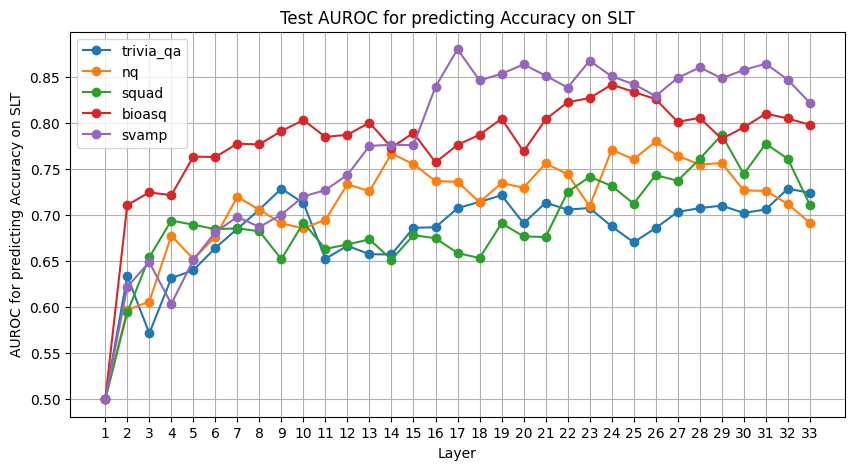

In [18]:
# Plot test AUROC curves for all on predicting Accuracy
plot_metrics([D.ta_aucs for D in Ds], [f"{D.name}" for D in Ds], f'AUROC for predicting Accuracy on TBG')
plot_metrics([D.sa_aucs for D in Ds], [f"{D.name}" for D in Ds], f'AUROC for predicting Accuracy on SLT')

In [19]:
# Report best metrics
best_metric([D.ta_aucs for D in Ds], train="Accuracy", test="Accuracy", ds=[[D.name]*2 for D in Ds])
best_metric([D.sa_aucs for D in Ds], token="SLT", train="Accuracy", test="Accuracy", ds=[[D.name]*2 for D in Ds])

TBG: max AUROC for LR trained on trivia_qa's Accuracy and tested on trivia_qa's Accuracy:
	- 0.8046 at layer 13
	- 0.7990 at layer 15
	- 0.7911 at layer 18
	- 0.7909 at layer 19
	- 0.7846 at layer 17
TBG: max AUROC for LR trained on nq's Accuracy and tested on nq's Accuracy:
	- 0.7386 at layer 18
	- 0.7359 at layer 19
	- 0.7192 at layer 20
	- 0.7179 at layer 17
	- 0.7169 at layer 31
TBG: max AUROC for LR trained on squad's Accuracy and tested on squad's Accuracy:
	- 0.7655 at layer 16
	- 0.7592 at layer 15
	- 0.7540 at layer 18
	- 0.7342 at layer 14
	- 0.7313 at layer 17
TBG: max AUROC for LR trained on bioasq's Accuracy and tested on bioasq's Accuracy:
	- 0.8450 at layer 9
	- 0.8417 at layer 25
	- 0.8347 at layer 26
	- 0.8193 at layer 24
	- 0.8185 at layer 17
TBG: max AUROC for LR trained on svamp's Accuracy and tested on svamp's Accuracy:
	- 0.9612 at layer 31
	- 0.9588 at layer 33
	- 0.9507 at layer 32
	- 0.9442 at layer 30
	- 0.9026 at layer 19
SLT: max AUROC for LR trained on triv

### Use linear probe trained on Binarized SE to predict Accuracy

Testing on trivia_qa-TBG 1/33
Test Loss: 0.7304, Test Accuracy: 0.5600, AUROC: 0.5484
Testing on trivia_qa-TBG 2/33
Test Loss: 0.7401, Test Accuracy: 0.5650, AUROC: 0.5896
Testing on trivia_qa-TBG 3/33
Test Loss: 0.7821, Test Accuracy: 0.5950, AUROC: 0.6077
Testing on trivia_qa-TBG 4/33
Test Loss: 0.8000, Test Accuracy: 0.5800, AUROC: 0.6206
Testing on trivia_qa-TBG 5/33
Test Loss: 0.9001, Test Accuracy: 0.5950, AUROC: 0.6198
Testing on trivia_qa-TBG 6/33
Test Loss: 0.9999, Test Accuracy: 0.5850, AUROC: 0.6263
Testing on trivia_qa-TBG 7/33
Test Loss: 1.0163, Test Accuracy: 0.6150, AUROC: 0.6407
Testing on trivia_qa-TBG 8/33
Test Loss: 1.0624, Test Accuracy: 0.6300, AUROC: 0.6465
Testing on trivia_qa-TBG 9/33
Test Loss: 1.1312, Test Accuracy: 0.6550, AUROC: 0.6789
Testing on trivia_qa-TBG 10/33
Test Loss: 1.1524, Test Accuracy: 0.6800, AUROC: 0.7214
Testing on trivia_qa-TBG 11/33
Test Loss: 1.1801, Test Accuracy: 0.6900, AUROC: 0.7211
Testing on trivia_qa-TBG 12/33
Test Loss: 1.0499, Te

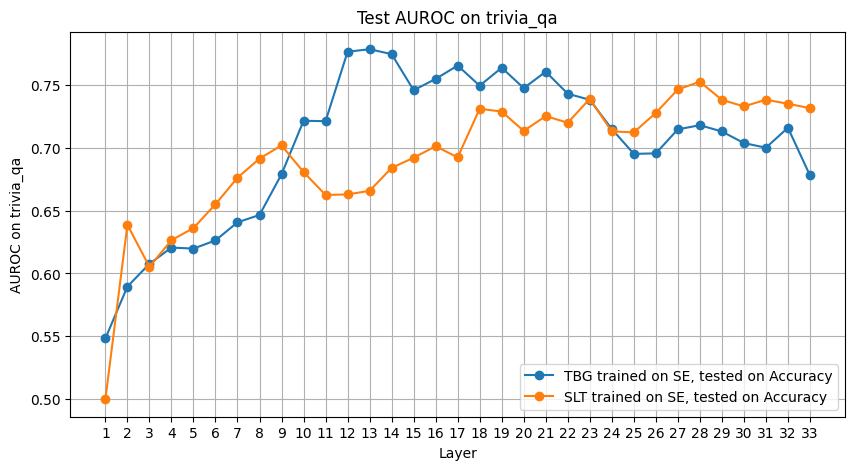

Testing on nq-TBG 1/33
Test Loss: 0.6231, Test Accuracy: 0.6550, AUROC: 0.5810
Testing on nq-TBG 2/33
Test Loss: 0.6442, Test Accuracy: 0.6350, AUROC: 0.5815
Testing on nq-TBG 3/33
Test Loss: 0.6659, Test Accuracy: 0.5950, AUROC: 0.5841
Testing on nq-TBG 4/33
Test Loss: 0.7211, Test Accuracy: 0.6050, AUROC: 0.5826
Testing on nq-TBG 5/33
Test Loss: 0.7926, Test Accuracy: 0.6200, AUROC: 0.6091
Testing on nq-TBG 6/33
Test Loss: 0.8180, Test Accuracy: 0.6100, AUROC: 0.6256
Testing on nq-TBG 7/33
Test Loss: 0.9348, Test Accuracy: 0.6300, AUROC: 0.6352
Testing on nq-TBG 8/33
Test Loss: 0.9927, Test Accuracy: 0.6300, AUROC: 0.6221
Testing on nq-TBG 9/33
Test Loss: 1.0293, Test Accuracy: 0.6250, AUROC: 0.6432
Testing on nq-TBG 10/33
Test Loss: 1.1515, Test Accuracy: 0.6350, AUROC: 0.6705
Testing on nq-TBG 11/33
Test Loss: 1.2197, Test Accuracy: 0.6350, AUROC: 0.6799
Testing on nq-TBG 12/33
Test Loss: 1.1617, Test Accuracy: 0.6400, AUROC: 0.6575
Testing on nq-TBG 13/33
Test Loss: 1.2172, Test A

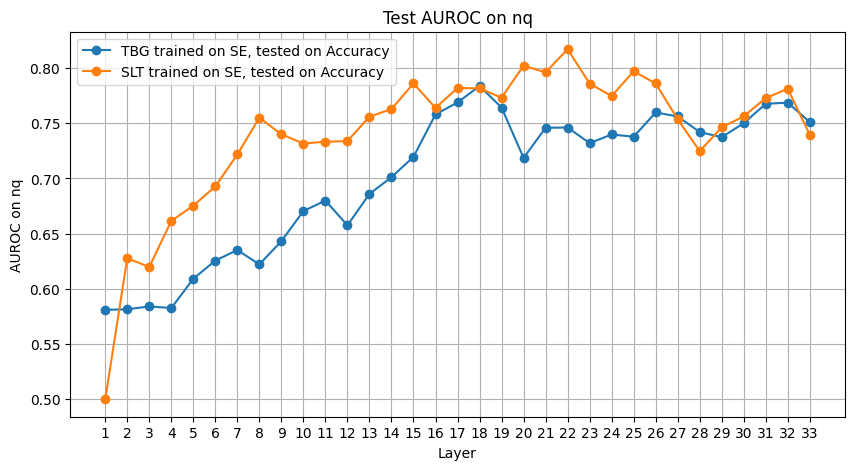

Testing on squad-TBG 1/33
Test Loss: 0.5600, Test Accuracy: 0.7400, AUROC: 0.6509
Testing on squad-TBG 2/33
Test Loss: 0.5736, Test Accuracy: 0.7300, AUROC: 0.6410
Testing on squad-TBG 3/33
Test Loss: 0.6052, Test Accuracy: 0.7300, AUROC: 0.6423
Testing on squad-TBG 4/33
Test Loss: 0.6187, Test Accuracy: 0.7450, AUROC: 0.6711
Testing on squad-TBG 5/33
Test Loss: 0.6778, Test Accuracy: 0.7150, AUROC: 0.6520
Testing on squad-TBG 6/33
Test Loss: 0.6964, Test Accuracy: 0.7500, AUROC: 0.6838
Testing on squad-TBG 7/33
Test Loss: 0.7766, Test Accuracy: 0.7700, AUROC: 0.6767
Testing on squad-TBG 8/33
Test Loss: 0.9583, Test Accuracy: 0.7050, AUROC: 0.6300
Testing on squad-TBG 9/33
Test Loss: 1.0925, Test Accuracy: 0.6950, AUROC: 0.6300
Testing on squad-TBG 10/33
Test Loss: 0.9333, Test Accuracy: 0.7500, AUROC: 0.7111
Testing on squad-TBG 11/33
Test Loss: 1.0056, Test Accuracy: 0.7200, AUROC: 0.7041
Testing on squad-TBG 12/33
Test Loss: 0.9021, Test Accuracy: 0.7550, AUROC: 0.7610
Testing on sq

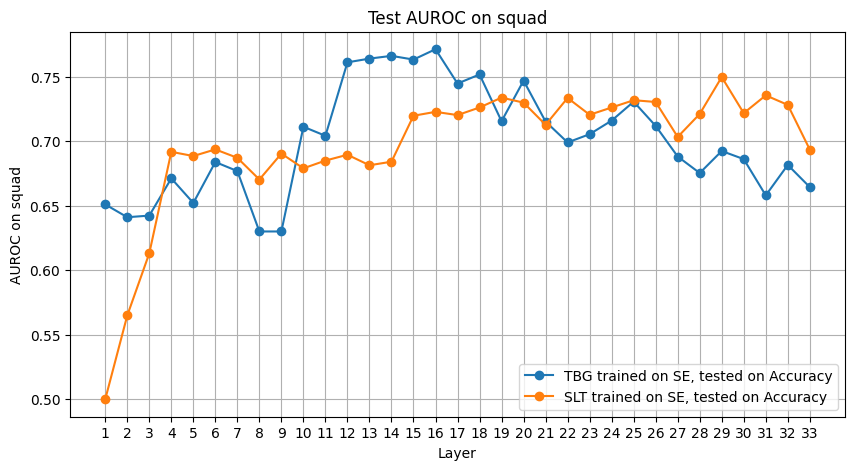

Testing on bioasq-TBG 1/33
Test Loss: 0.6822, Test Accuracy: 0.7450, AUROC: 0.7223
Testing on bioasq-TBG 2/33
Test Loss: 0.7232, Test Accuracy: 0.7400, AUROC: 0.7326
Testing on bioasq-TBG 3/33
Test Loss: 0.8172, Test Accuracy: 0.7350, AUROC: 0.7192
Testing on bioasq-TBG 4/33
Test Loss: 0.8712, Test Accuracy: 0.7000, AUROC: 0.7226
Testing on bioasq-TBG 5/33
Test Loss: 0.8638, Test Accuracy: 0.7100, AUROC: 0.7316
Testing on bioasq-TBG 6/33
Test Loss: 0.9225, Test Accuracy: 0.7200, AUROC: 0.7405
Testing on bioasq-TBG 7/33
Test Loss: 0.9400, Test Accuracy: 0.7400, AUROC: 0.7403
Testing on bioasq-TBG 8/33
Test Loss: 1.0426, Test Accuracy: 0.7350, AUROC: 0.7400
Testing on bioasq-TBG 9/33
Test Loss: 1.0852, Test Accuracy: 0.7250, AUROC: 0.7522
Testing on bioasq-TBG 10/33
Test Loss: 1.1532, Test Accuracy: 0.7350, AUROC: 0.7677
Testing on bioasq-TBG 11/33
Test Loss: 1.1190, Test Accuracy: 0.7800, AUROC: 0.7917
Testing on bioasq-TBG 12/33
Test Loss: 1.2290, Test Accuracy: 0.7500, AUROC: 0.7824
T

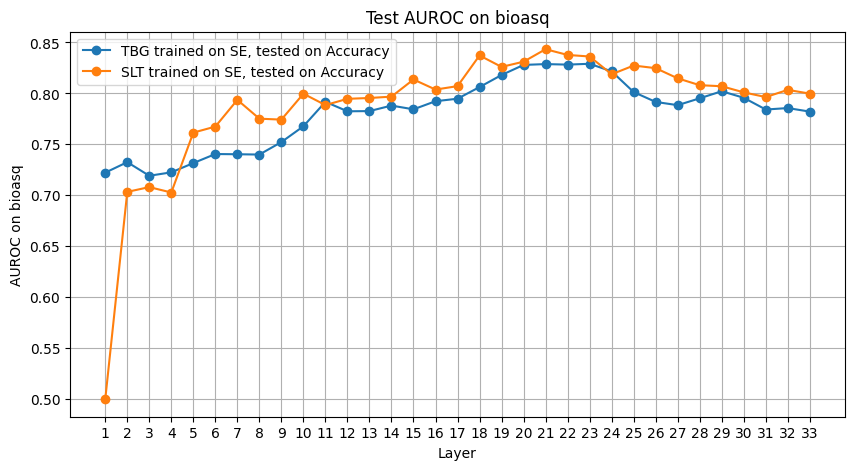

Testing on svamp-TBG 1/33
Test Loss: 0.8106, Test Accuracy: 0.5500, AUROC: 0.6042
Testing on svamp-TBG 2/33
Test Loss: 0.8365, Test Accuracy: 0.5500, AUROC: 0.5592
Testing on svamp-TBG 3/33
Test Loss: 0.9028, Test Accuracy: 0.5600, AUROC: 0.5810
Testing on svamp-TBG 4/33
Test Loss: 0.9054, Test Accuracy: 0.5800, AUROC: 0.5834
Testing on svamp-TBG 5/33
Test Loss: 0.9254, Test Accuracy: 0.5700, AUROC: 0.5891
Testing on svamp-TBG 6/33
Test Loss: 0.9932, Test Accuracy: 0.5700, AUROC: 0.5665
Testing on svamp-TBG 7/33
Test Loss: 1.0506, Test Accuracy: 0.5600, AUROC: 0.5483
Testing on svamp-TBG 8/33
Test Loss: 1.0967, Test Accuracy: 0.5700, AUROC: 0.5471
Testing on svamp-TBG 9/33
Test Loss: 1.1006, Test Accuracy: 0.5800, AUROC: 0.5814
Testing on svamp-TBG 10/33
Test Loss: 1.2569, Test Accuracy: 0.5700, AUROC: 0.5653
Testing on svamp-TBG 11/33
Test Loss: 1.4087, Test Accuracy: 0.6000, AUROC: 0.6347
Testing on svamp-TBG 12/33
Test Loss: 1.4202, Test Accuracy: 0.5900, AUROC: 0.6465
Testing on sv

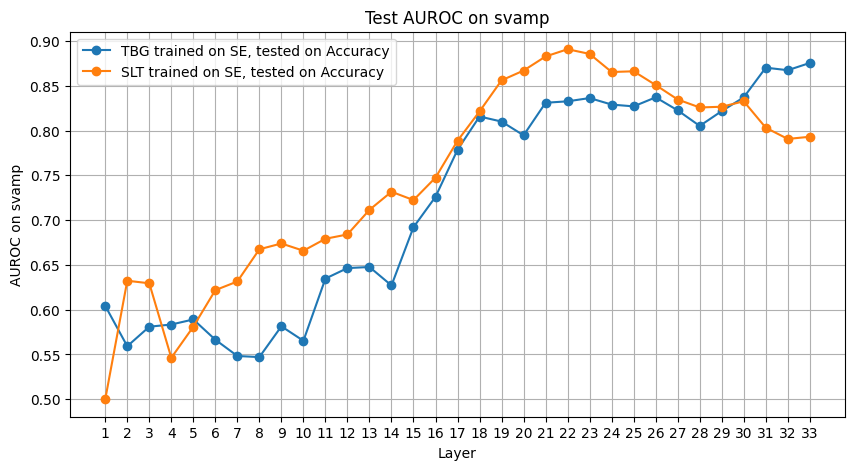

In [22]:
for D in Ds:
    r_acc = 1 - D.accuracies
    
    # TBG
    # X_trains, X_vals, _, y_trains, y_vals, _ = create_Xs_and_ys(D.tbg_dataset, D.b_entropy, D.total_size)
    _, _, X_tests, _, _, y_tests = create_Xs_and_ys(D.tbg_dataset, r_acc, D.total_size) 
    tab_accs = []
    tab_aucs = []
    
    for i, (X_test, y_test) in enumerate(zip(X_tests, y_tests)):
        print(f"Testing on {D.name}-TBG {i+1}/{len(X_tests)}")
        model = D.tb_models[i]
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
        tab_accs.append(test_acc)
        tab_aucs.append(test_auc)

    D.tab_accs = tab_accs
    D.tab_aucs = tab_aucs

    # SLT
    # X_trains, X_vals, _, y_trains, y_vals, _ = create_Xs_and_ys(D.slt_dataset, D.b_entropy, D.total_size)
    _, _, X_tests, _, _, y_tests = create_Xs_and_ys(D.slt_dataset, r_acc, D.total_size)     
    sab_accs = []
    sab_aucs = []
    
    for i, (X_test, y_test) in enumerate(zip(X_tests, y_tests)):
        print(f"Testing on {D.name}-SLT {i+1}/{len(X_tests)}")
        model = D.sb_models[i]
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
        sab_accs.append(test_acc)
        sab_aucs.append(test_auc)

    D.sab_accs = sab_accs
    D.sab_aucs = sab_aucs
    
    plot_metrics([tab_aucs, sab_aucs], ['TBG trained on SE, tested on Accuracy', 'SLT trained on SE, tested on Accuracy'], f'AUROC on {D.name}')

On TRIVIA_QA:


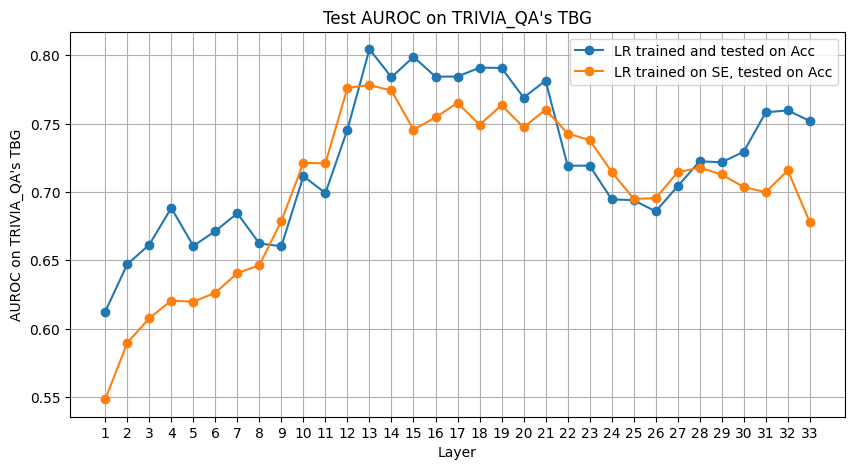

TBG: max AUROC for LR trained on TRIVIA_QA's SE and tested on TRIVIA_QA's Accuracy:
	- 0.7783 at layer 13
	- 0.7763 at layer 12
	- 0.7744 at layer 14
	- 0.7653 at layer 17
	- 0.7636 at layer 19
TBG: max AUROC for LR trained on TRIVIA_QA's Accuracy and tested on TRIVIA_QA's Accuracy:
	- 0.8046 at layer 13
	- 0.7990 at layer 15
	- 0.7911 at layer 18
	- 0.7909 at layer 19
	- 0.7846 at layer 17


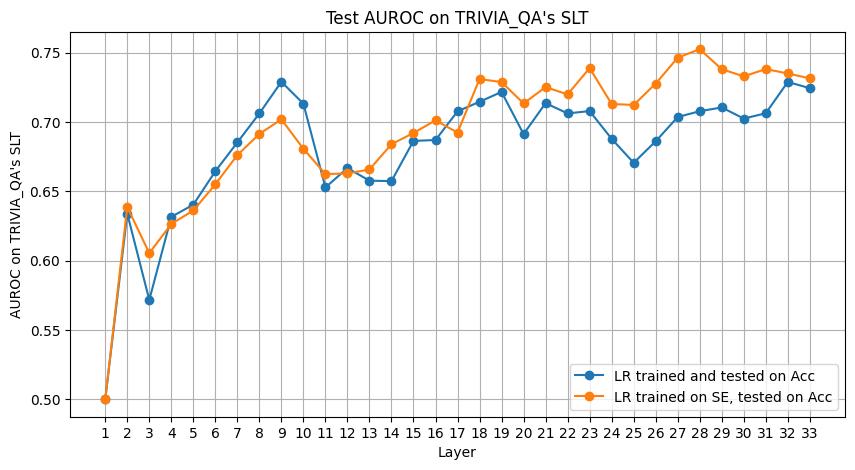

SLT: max AUROC for LR trained on TRIVIA_QA's SE and tested on TRIVIA_QA's Accuracy:
	- 0.7524 at layer 28
	- 0.7463 at layer 27
	- 0.7388 at layer 23
	- 0.7381 at layer 31
	- 0.7380 at layer 29
SLT: max AUROC for LR trained on TRIVIA_QA's Accuracy and tested on TRIVIA_QA's Accuracy:
	- 0.7289 at layer 9
	- 0.7288 at layer 32
	- 0.7243 at layer 33
	- 0.7216 at layer 19
	- 0.7145 at layer 18
On NQ:


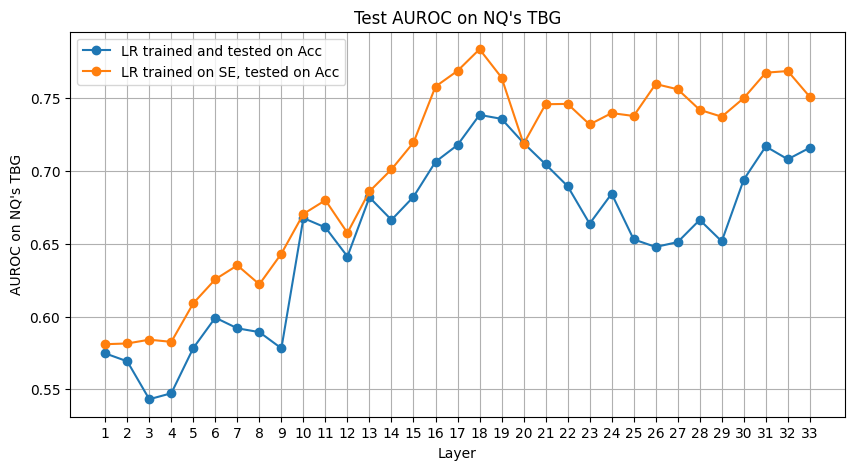

TBG: max AUROC for LR trained on NQ's SE and tested on NQ's Accuracy:
	- 0.7837 at layer 18
	- 0.7688 at layer 17
	- 0.7687 at layer 32
	- 0.7676 at layer 31
	- 0.7643 at layer 19
TBG: max AUROC for LR trained on NQ's Accuracy and tested on NQ's Accuracy:
	- 0.7386 at layer 18
	- 0.7359 at layer 19
	- 0.7192 at layer 20
	- 0.7179 at layer 17
	- 0.7169 at layer 31


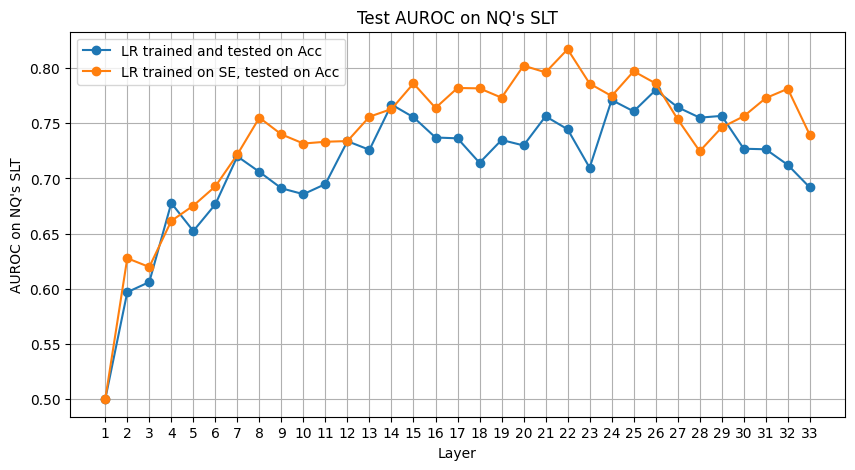

SLT: max AUROC for LR trained on NQ's SE and tested on NQ's Accuracy:
	- 0.8171 at layer 22
	- 0.8022 at layer 20
	- 0.7971 at layer 25
	- 0.7961 at layer 21
	- 0.7861 at layer 15
SLT: max AUROC for LR trained on NQ's Accuracy and tested on NQ's Accuracy:
	- 0.7801 at layer 26
	- 0.7711 at layer 24
	- 0.7670 at layer 14
	- 0.7645 at layer 27
	- 0.7608 at layer 25
On SQUAD:


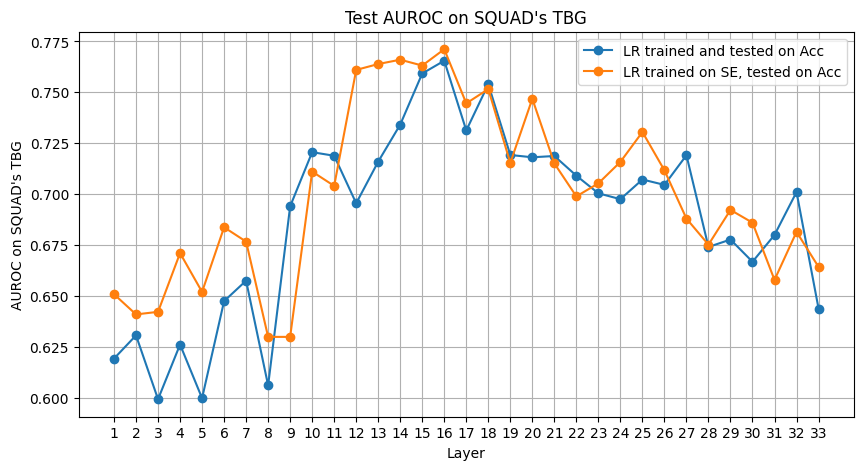

TBG: max AUROC for LR trained on SQUAD's SE and tested on SQUAD's Accuracy:
	- 0.7712 at layer 16
	- 0.7660 at layer 14
	- 0.7639 at layer 13
	- 0.7631 at layer 15
	- 0.7610 at layer 12
TBG: max AUROC for LR trained on SQUAD's Accuracy and tested on SQUAD's Accuracy:
	- 0.7655 at layer 16
	- 0.7592 at layer 15
	- 0.7540 at layer 18
	- 0.7342 at layer 14
	- 0.7313 at layer 17


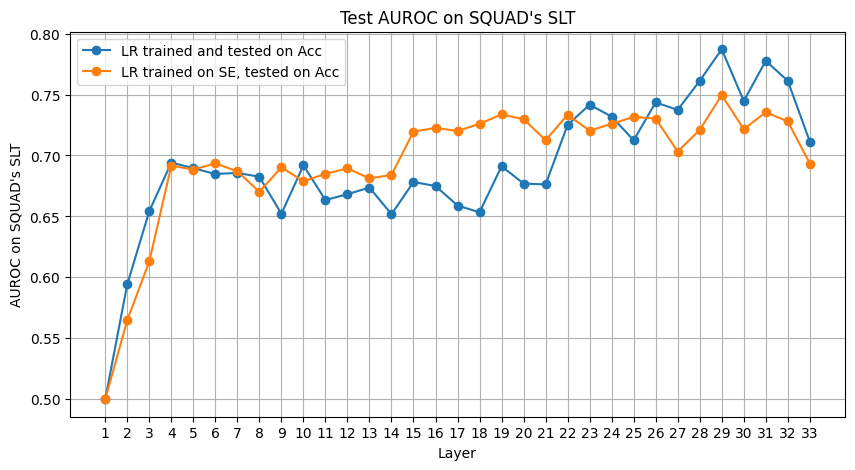

SLT: max AUROC for LR trained on SQUAD's SE and tested on SQUAD's Accuracy:
	- 0.7496 at layer 29
	- 0.7354 at layer 31
	- 0.7337 at layer 19
	- 0.7334 at layer 22
	- 0.7317 at layer 25
SLT: max AUROC for LR trained on SQUAD's Accuracy and tested on SQUAD's Accuracy:
	- 0.7872 at layer 29
	- 0.7777 at layer 31
	- 0.7613 at layer 32
	- 0.7613 at layer 28
	- 0.7447 at layer 30
On BIOASQ:


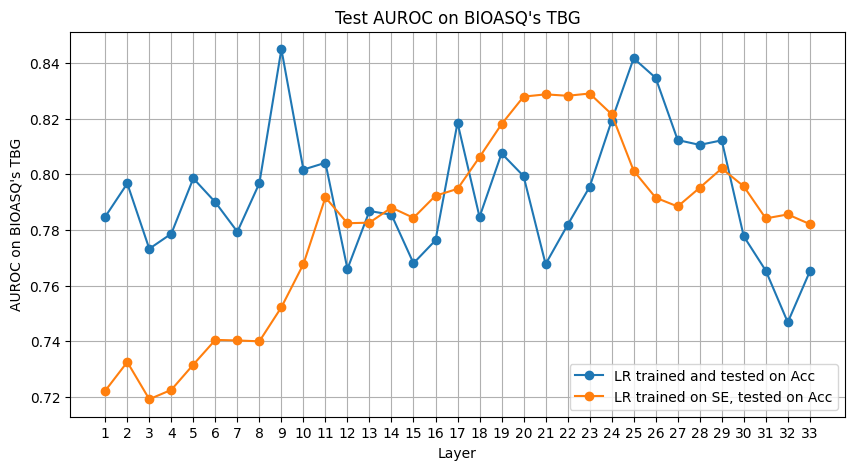

TBG: max AUROC for LR trained on BIOASQ's SE and tested on BIOASQ's Accuracy:
	- 0.8290 at layer 23
	- 0.8287 at layer 21
	- 0.8282 at layer 22
	- 0.8279 at layer 20
	- 0.8216 at layer 24
TBG: max AUROC for LR trained on BIOASQ's Accuracy and tested on BIOASQ's Accuracy:
	- 0.8450 at layer 9
	- 0.8417 at layer 25
	- 0.8347 at layer 26
	- 0.8193 at layer 24
	- 0.8185 at layer 17


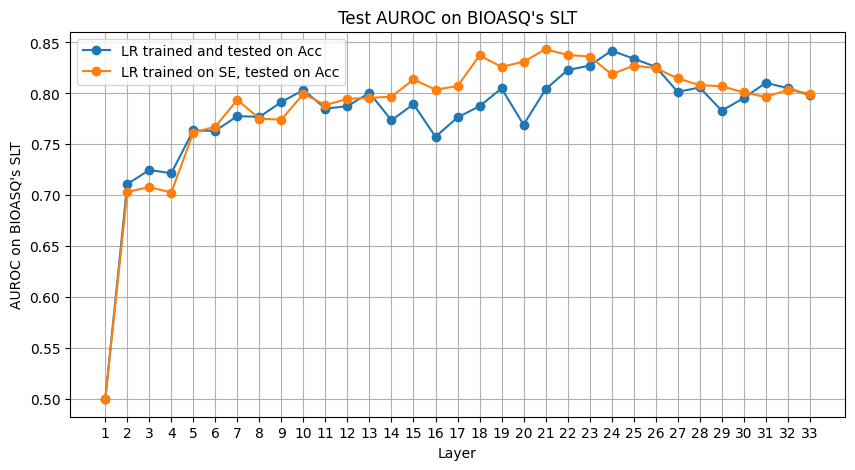

SLT: max AUROC for LR trained on BIOASQ's SE and tested on BIOASQ's Accuracy:
	- 0.8433 at layer 21
	- 0.8377 at layer 22
	- 0.8372 at layer 18
	- 0.8362 at layer 23
	- 0.8311 at layer 20
SLT: max AUROC for LR trained on BIOASQ's Accuracy and tested on BIOASQ's Accuracy:
	- 0.8419 at layer 24
	- 0.8340 at layer 25
	- 0.8273 at layer 23
	- 0.8261 at layer 26
	- 0.8228 at layer 22
On SVAMP:


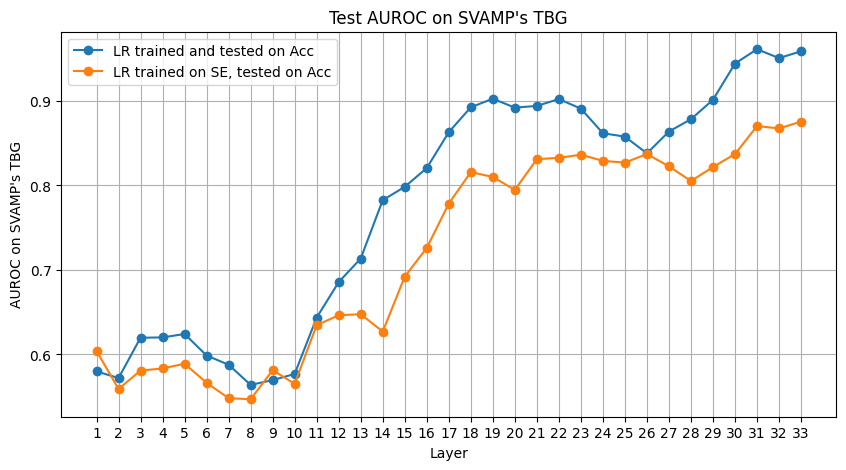

TBG: max AUROC for LR trained on SVAMP's SE and tested on SVAMP's Accuracy:
	- 0.8756 at layer 33
	- 0.8703 at layer 31
	- 0.8675 at layer 32
	- 0.8372 at layer 30
	- 0.8372 at layer 26
TBG: max AUROC for LR trained on SVAMP's Accuracy and tested on SVAMP's Accuracy:
	- 0.9612 at layer 31
	- 0.9588 at layer 33
	- 0.9507 at layer 32
	- 0.9442 at layer 30
	- 0.9026 at layer 19


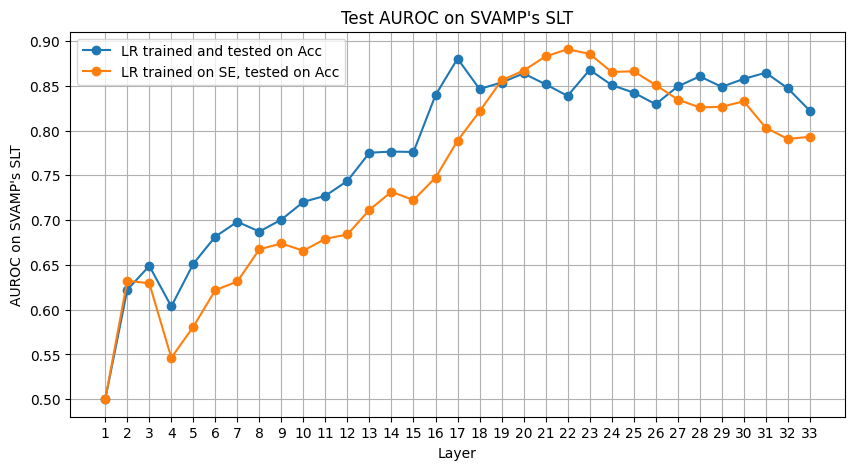

SLT: max AUROC for LR trained on SVAMP's SE and tested on SVAMP's Accuracy:
	- 0.8909 at layer 22
	- 0.8857 at layer 23
	- 0.8828 at layer 21
	- 0.8671 at layer 20
	- 0.8663 at layer 25
SLT: max AUROC for LR trained on SVAMP's Accuracy and tested on SVAMP's Accuracy:
	- 0.8804 at layer 17
	- 0.8679 at layer 23
	- 0.8646 at layer 31
	- 0.8638 at layer 20
	- 0.8606 at layer 28


In [25]:
for D in Ds:
    print(f"On {D.name.upper()}:")
    plot_metrics([D.ta_aucs, D.tab_aucs], ["LR trained and tested on Acc", "LR trained on SE, tested on Acc"], f"AUROC on {D.name.upper()}'s TBG")
    best_metric([D.tab_aucs], token="TBG", train="SE", test="Accuracy", ds=[[D.name.upper()]*2])
    best_metric([D.ta_aucs], token="TBG", train="Accuracy", test="Accuracy", ds=[[D.name.upper()]*2])
    plot_metrics([D.sa_aucs, D.sab_aucs], ["LR trained and tested on Acc", "LR trained on SE, tested on Acc"], f"AUROC on {D.name.upper()}'s SLT")
    best_metric([D.sab_aucs], token="SLT", train="SE", test="Accuracy", ds=[[D.name.upper()]*2])
    best_metric([D.sa_aucs], token="SLT", train="Accuracy", test="Accuracy", ds=[[D.name.upper()]*2])

## Generalize probes trained on 4 datasets' SE to the other's SE/Acc prediction

We will test probes **trained** on the union of different D's SLT SE.

In [26]:
# Utility to merge X's and y's (assume SLT)
def merge_Xs_and_ys(Ds, other_ids, attribute='b_entropy'):
    """Ds are the collection of dataset instances; other_ids are the other four datasets"""
    print("Merging datasets")
    all_Xs_and_ys = ()
    for id_ in other_ids:
        D = Ds[id_]
        # X_trains, X_vals, X_tests, y_trains, y_vals, y_tests
        Xs_and_ys = create_Xs_and_ys(D.slt_dataset, getattr(D, attribute), D.total_size)
        all_Xs_and_ys += (Xs_and_ys,)
    
    # merge xs and ys by splits
    all_splits = list(zip(*all_Xs_and_ys))
    results = ()
    for splits in all_splits:
        all_layers = [[] for _ in range(len(splits[0]))]
        for split in splits:
            for i, layer in enumerate(split):
                all_layers[i].append(layer)
        results += ([np.concatenate(l, axis=0) for l in all_layers],)

    print(f"Dummy test accuracy: {max(np.mean(results[-1]), 1-np.mean(results[-1])):.4f}")
    return results            

In [ ]:
# Test merge_Xs_and_ys
# results = merge_Xs_and_ys(Ds, [0,1,2])
# len(results), len(results[0]), results[5][0].shape

Training on datasets ['nq', 'squad', 'bioasq', 'svamp']'s SLT-SE to predict trivia_qa's SLT-Acc
Merging datasets
Dummy test accuracy: 0.5314
Training on SLT-SE 1/33 - ['nq', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.5429, AUROC: 0.5000
Training Loss: 0.6884, Validation Loss: 0.6895
Test Loss: 0.6918, Test Accuracy: 0.5314, AUROC: 0.5000
Training on SLT-SE 2/33 - ['nq', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.6905, AUROC: 0.7075
Training Loss: 0.6234, Validation Loss: 0.6221
Test Loss: 0.6259, Test Accuracy: 0.6900, AUROC: 0.6975
Training on SLT-SE 3/33 - ['nq', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.7000, AUROC: 0.7180
Training Loss: 0.6026, Validation Loss: 0.6061
Test Loss: 0.6054, Test Accuracy: 0.6957, AUROC: 0.7179
Training on SLT-SE 4/33 - ['nq', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.7175, AUROC: 0.7745
Training Loss: 0.5483, Validation Loss: 0.5613
Test Loss: 0.5684, Test Accuracy: 0.7043, AUROC: 0.7628
Training on SLT-SE 5/33 - ['nq'

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7349, AUROC: 0.8229
Training Loss: 0.4998, Validation Loss: 0.5140
Test Loss: 0.5473, Test Accuracy: 0.7229, AUROC: 0.7893
Training on SLT-SE 6/33 - ['nq', 'squad', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7317, AUROC: 0.8234
Training Loss: 0.4820, Validation Loss: 0.5116
Test Loss: 0.5386, Test Accuracy: 0.7300, AUROC: 0.7987
Training on SLT-SE 7/33 - ['nq', 'squad', 'bioasq', 'svamp']


...

Validation Accuracy: 0.7913, AUROC: 0.8559
Training Loss: 0.0015, Validation Loss: 3.4584
Test Loss: 3.6049, Test Accuracy: 0.7914, AUROC: 0.8472
Training on SLT-SE 32/33 - ['nq', 'squad', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7921, AUROC: 0.8572
Training Loss: 0.0023, Validation Loss: 3.4123
Test Loss: 3.9123, Test Accuracy: 0.7743, AUROC: 0.8319
Training on SLT-SE 33/33 - ['nq', 'squad', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7825, AUROC: 0.8491
Training Loss: 0.0054, Validation Loss: 1.8041
Test Loss: 2.2037, Test Accuracy: 0.7543, AUROC: 0.8156


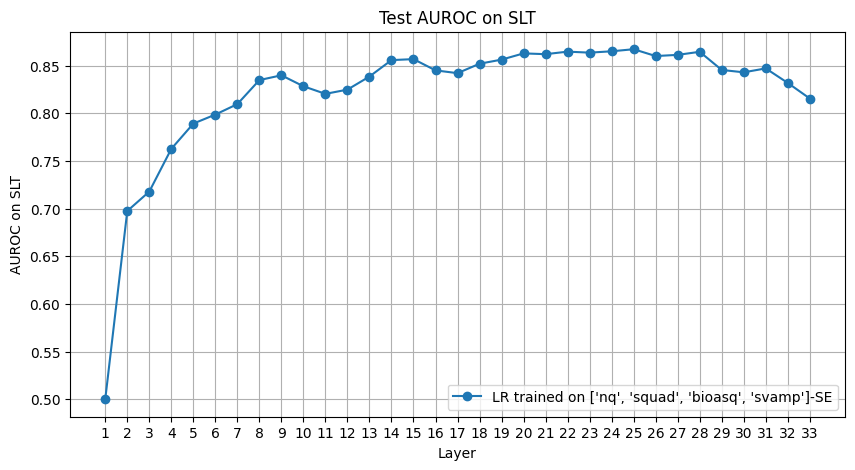

Training on datasets ['nq', 'squad', 'bioasq', 'svamp']'s SLT-Acc to predict trivia_qa's SLT-Acc
Merging datasets
Dummy test accuracy: 0.6400
Training on SLT-Acc 1/33 - ['nq', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.6413, AUROC: 0.5000
Training Loss: 0.6537, Validation Loss: 0.6527
Test Loss: 0.6534, Test Accuracy: 0.6400, AUROC: 0.5000
Training on SLT-Acc 2/33 - ['nq', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.6762, AUROC: 0.6979
Training Loss: 0.6154, Validation Loss: 0.6030
Test Loss: 0.6302, Test Accuracy: 0.6557, AUROC: 0.6161
Training on SLT-Acc 3/33 - ['nq', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.7063, AUROC: 0.6899
Training Loss: 0.6027, Validation Loss: 0.5948
Test Loss: 0.6207, Test Accuracy: 0.6886, AUROC: 0.6289
Training on SLT-Acc 4/33 - ['nq', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.7230, AUROC: 0.7122
Training Loss: 0.5704, Validation Loss: 0.5775
Test Loss: 0.5996, Test Accuracy: 0.6971, AUROC: 0.6805
Training on SLT-Acc 5/33 -

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7190, AUROC: 0.7380
Training Loss: 0.5403, Validation Loss: 0.5650
Test Loss: 0.5730, Test Accuracy: 0.7000, AUROC: 0.7367
Training on SLT-Acc 6/33 - ['nq', 'squad', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7254, AUROC: 0.7364
Training Loss: 0.5263, Validation Loss: 0.5656
Test Loss: 0.5702, Test Accuracy: 0.7114, AUROC: 0.7403
Training on SLT-Acc 7/33 - ['nq', 'squad', 'bioasq', 'svamp']


...

Validation Accuracy: 0.7095, AUROC: 0.7295
Training Loss: 0.0093, Validation Loss: 5.7009
Test Loss: 5.3997, Test Accuracy: 0.7086, AUROC: 0.7488
Training on SLT-Acc 32/33 - ['nq', 'squad', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6968, AUROC: 0.7232
Training Loss: 0.0235, Validation Loss: 5.1488
Test Loss: 4.7972, Test Accuracy: 0.6886, AUROC: 0.7306
Training on SLT-Acc 33/33 - ['nq', 'squad', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6944, AUROC: 0.7265
Training Loss: 0.0280, Validation Loss: 2.8585
Test Loss: 2.8662, Test Accuracy: 0.6786, AUROC: 0.7256


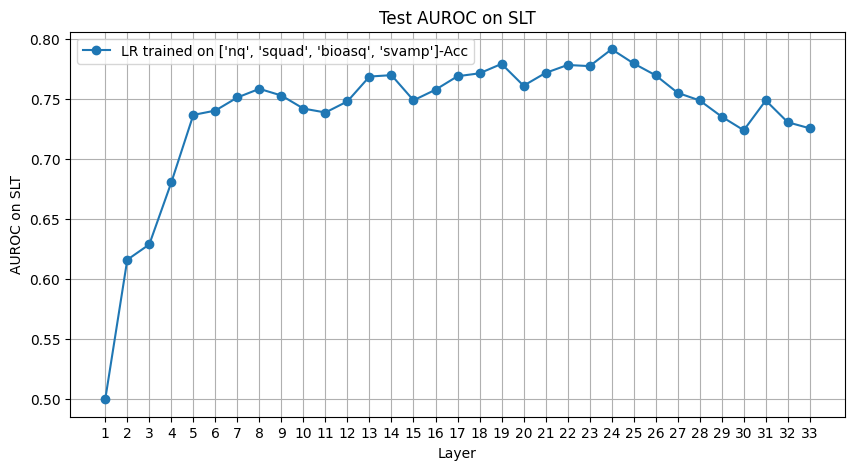

Training on datasets ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SLT-SE to predict nq's SLT-Acc
Merging datasets
Dummy test accuracy: 0.5186
Training on SLT-SE 1/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.5079, AUROC: 0.5000
Training Loss: 0.6931, Validation Loss: 0.6930
Test Loss: 0.6928, Test Accuracy: 0.5186, AUROC: 0.5000
Training on SLT-SE 2/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.6754, AUROC: 0.7245
Training Loss: 0.6260, Validation Loss: 0.6230
Test Loss: 0.6168, Test Accuracy: 0.6943, AUROC: 0.7356
Training on SLT-SE 3/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.6889, AUROC: 0.7330
Training Loss: 0.6027, Validation Loss: 0.6096
Test Loss: 0.5962, Test Accuracy: 0.7171, AUROC: 0.7514
Training on SLT-SE 4/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.7103, AUROC: 0.7743
Training Loss: 0.5517, Validation Loss: 0.5706
Test Loss: 0.5590, Test Accuracy: 0.7243, AUROC: 0.7855
Tra

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7206, AUROC: 0.7999
Training Loss: 0.4985, Validation Loss: 0.5402
Test Loss: 0.5288, Test Accuracy: 0.7443, AUROC: 0.8048
Training on SLT-SE 6/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7302, AUROC: 0.7993
Training Loss: 0.4813, Validation Loss: 0.5407
Test Loss: 0.5139, Test Accuracy: 0.7543, AUROC: 0.8197
Training on SLT-SE 7/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']


...

Validation Accuracy: 0.7690, AUROC: 0.8321
Training Loss: 0.0040, Validation Loss: 3.7504
Test Loss: 3.5465, Test Accuracy: 0.7914, AUROC: 0.8463
Training on SLT-SE 32/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7619, AUROC: 0.8315
Training Loss: 0.0039, Validation Loss: 4.0323
Test Loss: 3.9461, Test Accuracy: 0.7886, AUROC: 0.8451
Training on SLT-SE 33/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7619, AUROC: 0.8256
Training Loss: 0.0087, Validation Loss: 2.1215
Test Loss: 2.1521, Test Accuracy: 0.7857, AUROC: 0.8281


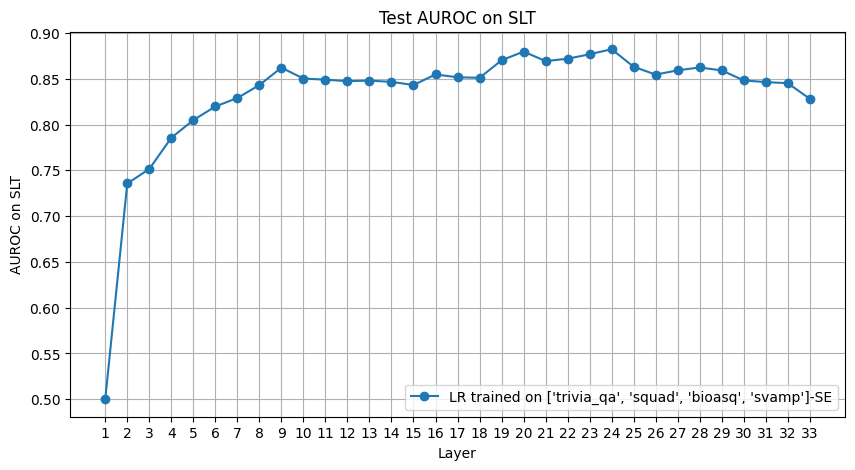

Training on datasets ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SLT-Acc to predict nq's SLT-Acc
Merging datasets
Dummy test accuracy: 0.5786
Training on SLT-Acc 1/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.5841, AUROC: 0.5000
Training Loss: 0.6822, Validation Loss: 0.6791
Test Loss: 0.6808, Test Accuracy: 0.5786, AUROC: 0.5000
Training on SLT-Acc 2/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.6405, AUROC: 0.6874
Training Loss: 0.6466, Validation Loss: 0.6338
Test Loss: 0.6564, Test Accuracy: 0.6200, AUROC: 0.6293
Training on SLT-Acc 3/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.6556, AUROC: 0.6907
Training Loss: 0.6337, Validation Loss: 0.6266
Test Loss: 0.6466, Test Accuracy: 0.6486, AUROC: 0.6529
Training on SLT-Acc 4/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']
Validation Accuracy: 0.6611, AUROC: 0.7141
Training Loss: 0.6043, Validation Loss: 0.6109
Test Loss: 0.6270, Test Accuracy: 0.6586, AUROC: 0.687

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6802, AUROC: 0.7304
Training Loss: 0.5730, Validation Loss: 0.5981
Test Loss: 0.6026, Test Accuracy: 0.6529, AUROC: 0.7259
Training on SLT-Acc 6/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6873, AUROC: 0.7349
Training Loss: 0.5551, Validation Loss: 0.5928
Test Loss: 0.5951, Test Accuracy: 0.6743, AUROC: 0.7365
Training on SLT-Acc 7/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']


...

Validation Accuracy: 0.6675, AUROC: 0.7144
Training Loss: 0.0620, Validation Loss: 3.9832
Test Loss: 3.5219, Test Accuracy: 0.7057, AUROC: 0.7478
Training on SLT-Acc 32/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6786, AUROC: 0.7249
Training Loss: 0.0500, Validation Loss: 4.9848
Test Loss: 4.4064, Test Accuracy: 0.7143, AUROC: 0.7495
Training on SLT-Acc 33/33 - ['trivia_qa', 'squad', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6714, AUROC: 0.7154
Training Loss: 0.0336, Validation Loss: 3.2285
Test Loss: 3.0189, Test Accuracy: 0.6771, AUROC: 0.7268


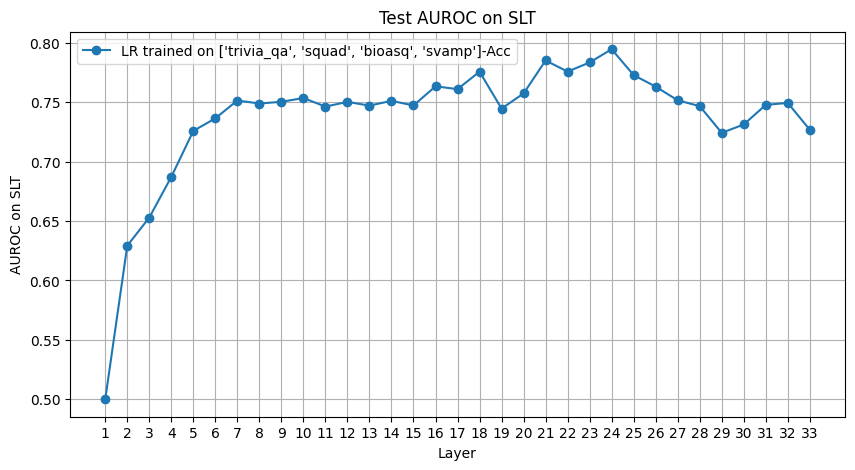

Training on datasets ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SLT-SE to predict squad's SLT-Acc
Merging datasets
Dummy test accuracy: 0.5229
Training on SLT-SE 1/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']
Validation Accuracy: 0.5167, AUROC: 0.5000
Training Loss: 0.6928, Validation Loss: 0.6926
Test Loss: 0.6923, Test Accuracy: 0.5229, AUROC: 0.5000
Training on SLT-SE 2/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']
Validation Accuracy: 0.6302, AUROC: 0.6827
Training Loss: 0.6443, Validation Loss: 0.6482
Test Loss: 0.6467, Test Accuracy: 0.6343, AUROC: 0.6754
Training on SLT-SE 3/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']
Validation Accuracy: 0.6548, AUROC: 0.7070
Training Loss: 0.6217, Validation Loss: 0.6307
Test Loss: 0.6294, Test Accuracy: 0.6557, AUROC: 0.7036
Training on SLT-SE 4/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']
Validation Accuracy: 0.6849, AUROC: 0.7592
Training Loss: 0.5617, Validation Loss: 0.5845
Test Loss: 0.5829, Test Accuracy: 0.6914, AUROC: 0.7548
Training on SLT

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7056, AUROC: 0.8002
Training Loss: 0.5061, Validation Loss: 0.5448
Test Loss: 0.5478, Test Accuracy: 0.7214, AUROC: 0.7908
Training on SLT-SE 6/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7063, AUROC: 0.8038
Training Loss: 0.4826, Validation Loss: 0.5394
Test Loss: 0.5384, Test Accuracy: 0.7229, AUROC: 0.8010
Training on SLT-SE 7/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']


...

Validation Accuracy: 0.7825, AUROC: 0.8489
Training Loss: 0.0050, Validation Loss: 3.5553
Test Loss: 3.8702, Test Accuracy: 0.7657, AUROC: 0.8316
Training on SLT-SE 32/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7857, AUROC: 0.8463
Training Loss: 0.0043, Validation Loss: 3.8323
Test Loss: 4.2494, Test Accuracy: 0.7586, AUROC: 0.8298
Training on SLT-SE 33/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7730, AUROC: 0.8320
Training Loss: 0.0094, Validation Loss: 1.9187
Test Loss: 1.9821, Test Accuracy: 0.7643, AUROC: 0.8214


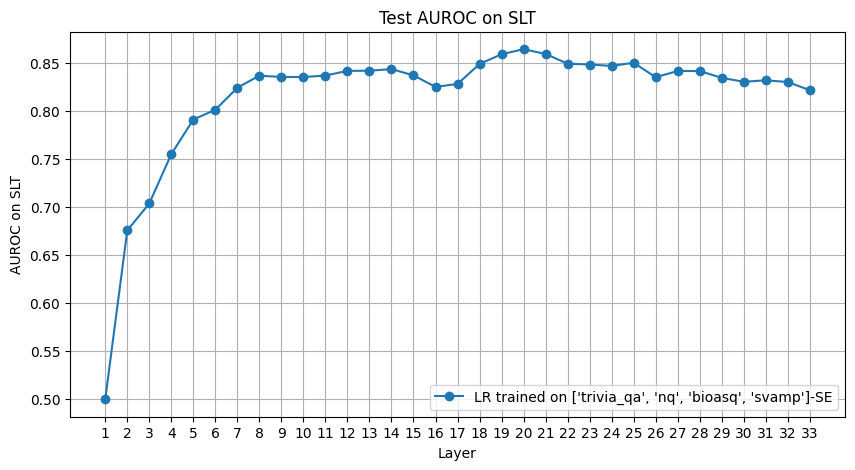

Training on datasets ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SLT-Acc to predict squad's SLT-Acc
Merging datasets
Dummy test accuracy: 0.5771
Training on SLT-Acc 1/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']
Validation Accuracy: 0.5706, AUROC: 0.5000
Training Loss: 0.6832, Validation Loss: 0.6831
Test Loss: 0.6813, Test Accuracy: 0.5771, AUROC: 0.5000
Training on SLT-Acc 2/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']
Validation Accuracy: 0.6071, AUROC: 0.6461
Training Loss: 0.6528, Validation Loss: 0.6533
Test Loss: 0.6608, Test Accuracy: 0.5957, AUROC: 0.6165
Training on SLT-Acc 3/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']
Validation Accuracy: 0.6278, AUROC: 0.6584
Training Loss: 0.6402, Validation Loss: 0.6457
Test Loss: 0.6528, Test Accuracy: 0.6186, AUROC: 0.6404
Training on SLT-Acc 4/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']
Validation Accuracy: 0.6484, AUROC: 0.6951
Training Loss: 0.6078, Validation Loss: 0.6256
Test Loss: 0.6279, Test Accuracy: 0.6586, AUROC: 0.6871
Training o

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6714, AUROC: 0.7184
Training Loss: 0.5757, Validation Loss: 0.6107
Test Loss: 0.6094, Test Accuracy: 0.6614, AUROC: 0.7137
Training on SLT-Acc 6/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6659, AUROC: 0.7231
Training Loss: 0.5568, Validation Loss: 0.6069
Test Loss: 0.6012, Test Accuracy: 0.6771, AUROC: 0.7257
Training on SLT-Acc 7/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']


...

Validation Accuracy: 0.6690, AUROC: 0.7067
Training Loss: 0.0373, Validation Loss: 4.8997
Test Loss: 4.4415, Test Accuracy: 0.6843, AUROC: 0.7190
Training on SLT-Acc 32/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6595, AUROC: 0.6964
Training Loss: 0.0459, Validation Loss: 4.9978
Test Loss: 4.7564, Test Accuracy: 0.6657, AUROC: 0.7041
Training on SLT-Acc 33/33 - ['trivia_qa', 'nq', 'bioasq', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6548, AUROC: 0.6933
Training Loss: 0.0293, Validation Loss: 3.6935
Test Loss: 3.5438, Test Accuracy: 0.6614, AUROC: 0.6961


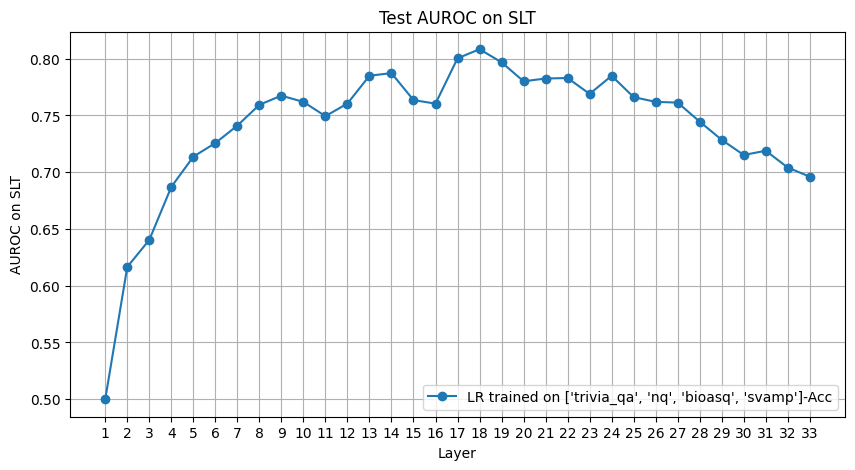

Training on datasets ['trivia_qa', 'nq', 'squad', 'svamp']'s SLT-SE to predict bioasq's SLT-Acc
Merging datasets
Dummy test accuracy: 0.5443
Training on SLT-SE 1/33 - ['trivia_qa', 'nq', 'squad', 'svamp']
Validation Accuracy: 0.5476, AUROC: 0.5000
Training Loss: 0.6889, Validation Loss: 0.6886
Test Loss: 0.6892, Test Accuracy: 0.5443, AUROC: 0.5000
Training on SLT-SE 2/33 - ['trivia_qa', 'nq', 'squad', 'svamp']
Validation Accuracy: 0.6476, AUROC: 0.6912
Training Loss: 0.6314, Validation Loss: 0.6311
Test Loss: 0.6316, Test Accuracy: 0.6557, AUROC: 0.6779
Training on SLT-SE 3/33 - ['trivia_qa', 'nq', 'squad', 'svamp']
Validation Accuracy: 0.6698, AUROC: 0.7071
Training Loss: 0.6189, Validation Loss: 0.6217
Test Loss: 0.6210, Test Accuracy: 0.6814, AUROC: 0.6984
Training on SLT-SE 4/33 - ['trivia_qa', 'nq', 'squad', 'svamp']
Validation Accuracy: 0.6722, AUROC: 0.7537
Training Loss: 0.5926, Validation Loss: 0.5965
Test Loss: 0.5973, Test Accuracy: 0.6843, AUROC: 0.7346
Training on SLT-SE 

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6881, AUROC: 0.7675
Training Loss: 0.5594, Validation Loss: 0.5816
Test Loss: 0.5824, Test Accuracy: 0.6986, AUROC: 0.7576
Training on SLT-SE 6/33 - ['trivia_qa', 'nq', 'squad', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6905, AUROC: 0.7646
Training Loss: 0.5409, Validation Loss: 0.5825
Test Loss: 0.5746, Test Accuracy: 0.7029, AUROC: 0.7659
Training on SLT-SE 7/33 - ['trivia_qa', 'nq', 'squad', 'svamp']


...

Validation Accuracy: 0.7587, AUROC: 0.8087
Training Loss: 0.0040, Validation Loss: 4.6312
Test Loss: 4.3101, Test Accuracy: 0.7557, AUROC: 0.8153
Training on SLT-SE 32/33 - ['trivia_qa', 'nq', 'squad', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7444, AUROC: 0.8043
Training Loss: 0.0039, Validation Loss: 4.6683
Test Loss: 4.5034, Test Accuracy: 0.7586, AUROC: 0.8079
Training on SLT-SE 33/33 - ['trivia_qa', 'nq', 'squad', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7389, AUROC: 0.8004
Training Loss: 0.0086, Validation Loss: 2.6103
Test Loss: 2.6711, Test Accuracy: 0.7257, AUROC: 0.7901


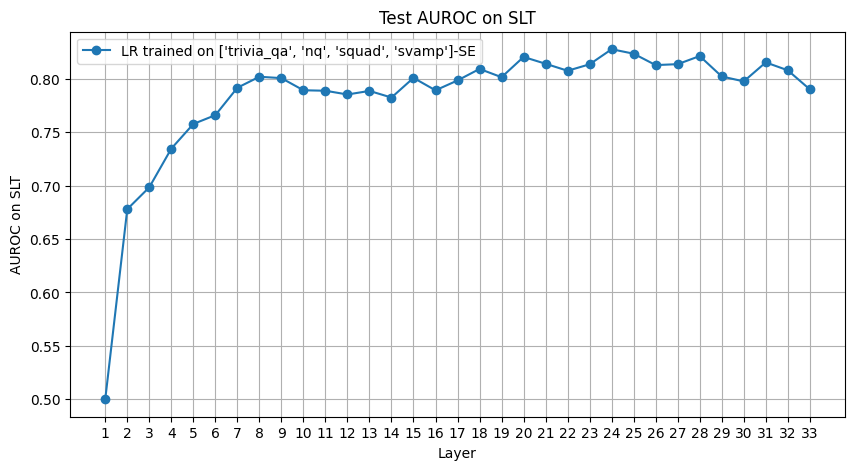

Training on datasets ['trivia_qa', 'nq', 'squad', 'svamp']'s SLT-Acc to predict bioasq's SLT-Acc
Merging datasets
Dummy test accuracy: 0.6214
Training on SLT-Acc 1/33 - ['trivia_qa', 'nq', 'squad', 'svamp']
Validation Accuracy: 0.6437, AUROC: 0.5000
Training Loss: 0.6590, Validation Loss: 0.6517
Test Loss: 0.6635, Test Accuracy: 0.6214, AUROC: 0.5000
Training on SLT-Acc 2/33 - ['trivia_qa', 'nq', 'squad', 'svamp']
Validation Accuracy: 0.6794, AUROC: 0.6918
Training Loss: 0.6173, Validation Loss: 0.6054
Test Loss: 0.6362, Test Accuracy: 0.6400, AUROC: 0.6351
Training on SLT-Acc 3/33 - ['trivia_qa', 'nq', 'squad', 'svamp']
Validation Accuracy: 0.6881, AUROC: 0.7003
Training Loss: 0.6087, Validation Loss: 0.5991
Test Loss: 0.6271, Test Accuracy: 0.6457, AUROC: 0.6632
Training on SLT-Acc 4/33 - ['trivia_qa', 'nq', 'squad', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6857, AUROC: 0.7115
Training Loss: 0.5903, Validation Loss: 0.5901
Test Loss: 0.6115, Test Accuracy: 0.6714, AUROC: 0.6981
Training on SLT-Acc 5/33 - ['trivia_qa', 'nq', 'squad', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6921, AUROC: 0.7197
Training Loss: 0.5646, Validation Loss: 0.5826
Test Loss: 0.5981, Test Accuracy: 0.6614, AUROC: 0.7098
Training on SLT-Acc 6/33 - ['trivia_qa', 'nq', 'squad', 'svamp']


...

Validation Accuracy: 0.6794, AUROC: 0.6902
Training Loss: 0.0091, Validation Loss: 6.4616
Test Loss: 6.2610, Test Accuracy: 0.6900, AUROC: 0.7039
Training on SLT-Acc 32/33 - ['trivia_qa', 'nq', 'squad', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6778, AUROC: 0.7037
Training Loss: 0.0084, Validation Loss: 6.7906
Test Loss: 6.2112, Test Accuracy: 0.6814, AUROC: 0.7120
Training on SLT-Acc 33/33 - ['trivia_qa', 'nq', 'squad', 'svamp']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6706, AUROC: 0.6910
Training Loss: 0.0202, Validation Loss: 3.5472
Test Loss: 3.2628, Test Accuracy: 0.6786, AUROC: 0.7009


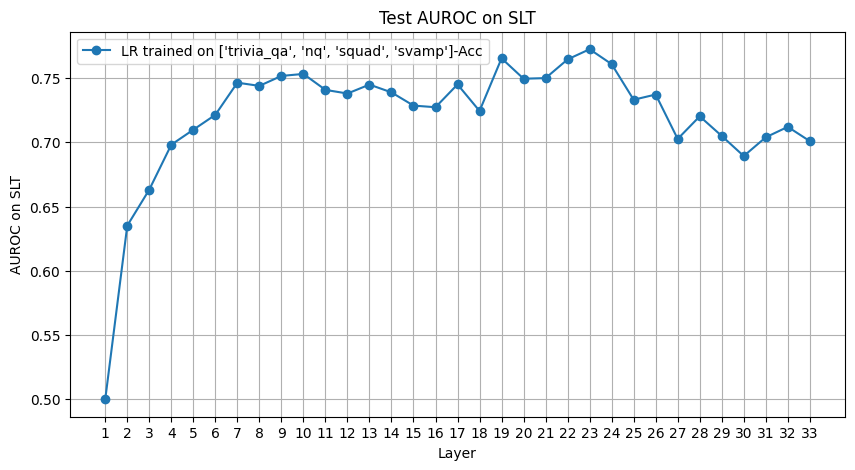

Training on datasets ['trivia_qa', 'nq', 'squad', 'bioasq']'s SLT-SE to predict svamp's SLT-Acc
Merging datasets
Dummy test accuracy: 0.5725
Training on SLT-SE 1/33 - ['trivia_qa', 'nq', 'squad', 'bioasq']
Validation Accuracy: 0.5701, AUROC: 0.5000
Training Loss: 0.6822, Validation Loss: 0.6833
Test Loss: 0.6826, Test Accuracy: 0.5725, AUROC: 0.5000
Training on SLT-SE 2/33 - ['trivia_qa', 'nq', 'squad', 'bioasq']
Validation Accuracy: 0.6528, AUROC: 0.6686
Training Loss: 0.6527, Validation Loss: 0.6490
Test Loss: 0.6531, Test Accuracy: 0.6375, AUROC: 0.6490
Training on SLT-SE 3/33 - ['trivia_qa', 'nq', 'squad', 'bioasq']
Validation Accuracy: 0.6528, AUROC: 0.6856
Training Loss: 0.6304, Validation Loss: 0.6344
Test Loss: 0.6343, Test Accuracy: 0.6575, AUROC: 0.6777
Training on SLT-SE 4/33 - ['trivia_qa', 'nq', 'squad', 'bioasq']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6778, AUROC: 0.7509
Training Loss: 0.5745, Validation Loss: 0.5872
Test Loss: 0.5942, Test Accuracy: 0.6850, AUROC: 0.7260
Training on SLT-SE 5/33 - ['trivia_qa', 'nq', 'squad', 'bioasq']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6993, AUROC: 0.7838
Training Loss: 0.5229, Validation Loss: 0.5510
Test Loss: 0.5644, Test Accuracy: 0.6963, AUROC: 0.7575
Training on SLT-SE 6/33 - ['trivia_qa', 'nq', 'squad', 'bioasq']


...

Validation Accuracy: 0.7701, AUROC: 0.8319
Training Loss: 0.0032, Validation Loss: 4.2588
Test Loss: 4.1393, Test Accuracy: 0.7812, AUROC: 0.8388
Training on SLT-SE 32/33 - ['trivia_qa', 'nq', 'squad', 'bioasq']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7549, AUROC: 0.8292
Training Loss: 0.0032, Validation Loss: 4.1072
Test Loss: 4.4359, Test Accuracy: 0.7650, AUROC: 0.8225
Training on SLT-SE 33/33 - ['trivia_qa', 'nq', 'squad', 'bioasq']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7542, AUROC: 0.8110
Training Loss: 0.0081, Validation Loss: 2.3788
Test Loss: 2.4302, Test Accuracy: 0.7375, AUROC: 0.8013


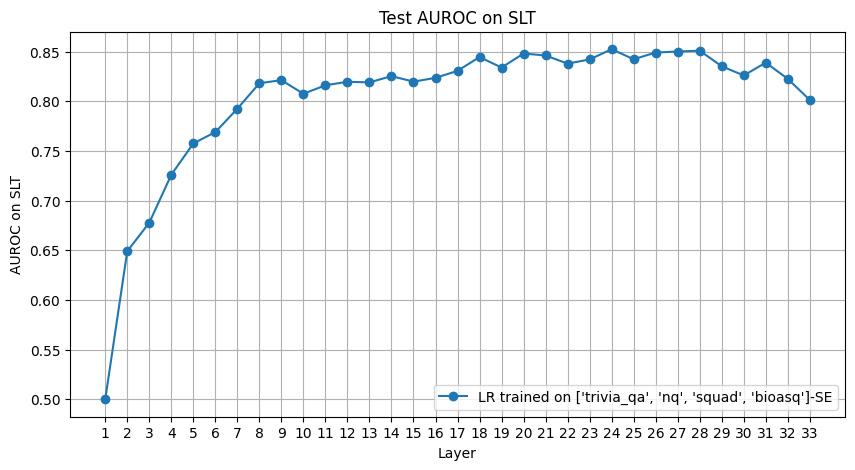

Training on datasets ['trivia_qa', 'nq', 'squad', 'bioasq']'s SLT-Acc to predict svamp's SLT-Acc
Merging datasets
Dummy test accuracy: 0.6300
Training on SLT-Acc 1/33 - ['trivia_qa', 'nq', 'squad', 'bioasq']
Validation Accuracy: 0.6486, AUROC: 0.5000
Training Loss: 0.6545, Validation Loss: 0.6485
Test Loss: 0.6591, Test Accuracy: 0.6300, AUROC: 0.5000
Training on SLT-Acc 2/33 - ['trivia_qa', 'nq', 'squad', 'bioasq']
Validation Accuracy: 0.6535, AUROC: 0.6559
Training Loss: 0.6284, Validation Loss: 0.6189
Test Loss: 0.6414, Test Accuracy: 0.6375, AUROC: 0.6043
Training on SLT-Acc 3/33 - ['trivia_qa', 'nq', 'squad', 'bioasq']
Validation Accuracy: 0.6597, AUROC: 0.6691
Training Loss: 0.6136, Validation Loss: 0.6097
Test Loss: 0.6285, Test Accuracy: 0.6525, AUROC: 0.6513
Training on SLT-Acc 4/33 - ['trivia_qa', 'nq', 'squad', 'bioasq']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6924, AUROC: 0.6959
Training Loss: 0.5870, Validation Loss: 0.5942
Test Loss: 0.6033, Test Accuracy: 0.6863, AUROC: 0.6919
Training on SLT-Acc 5/33 - ['trivia_qa', 'nq', 'squad', 'bioasq']
Validation Accuracy: 0.7021, AUROC: 0.7159
Training Loss: 0.5554, Validation Loss: 0.5833
Test Loss: 0.5806, Test Accuracy: 0.6863, AUROC: 0.7313
Training on SLT-Acc 6/33 - ['trivia_qa', 'nq', 'squad', 'bioasq']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6958, AUROC: 0.7153
Training Loss: 0.5480, Validation Loss: 0.5832
Test Loss: 0.5771, Test Accuracy: 0.6937, AUROC: 0.7344
Training on SLT-Acc 7/33 - ['trivia_qa', 'nq', 'squad', 'bioasq']


...

Validation Accuracy: 0.6708, AUROC: 0.6837
Training Loss: 0.0129, Validation Loss: 7.1704
Test Loss: 6.3631, Test Accuracy: 0.6787, AUROC: 0.7094
Training on SLT-Acc 32/33 - ['trivia_qa', 'nq', 'squad', 'bioasq']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6597, AUROC: 0.6874
Training Loss: 0.0277, Validation Loss: 6.3821
Test Loss: 6.1667, Test Accuracy: 0.6850, AUROC: 0.7031
Training on SLT-Acc 33/33 - ['trivia_qa', 'nq', 'squad', 'bioasq']


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6535, AUROC: 0.6729
Training Loss: 0.0284, Validation Loss: 3.7401
Test Loss: 3.6348, Test Accuracy: 0.6787, AUROC: 0.6959


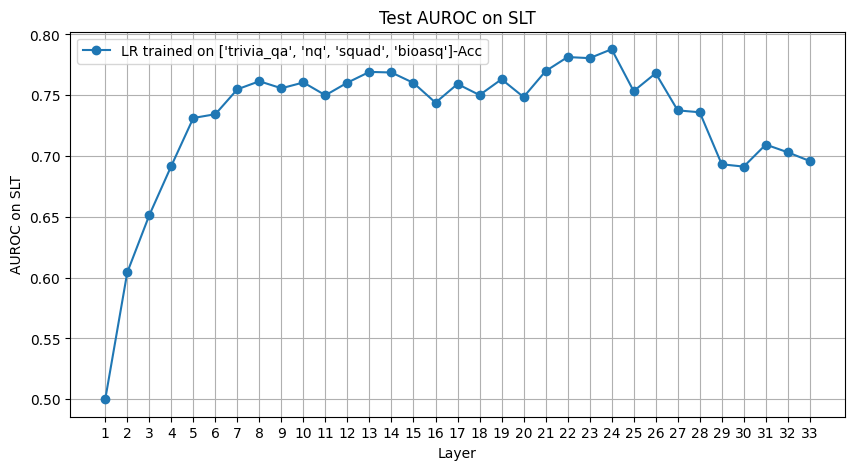

In [27]:
# Train
from sklearn.base import clone

for i, D in enumerate(Ds):
    other_ids = D.other_ids
    other_names = D.other_names
    
    print(f"Training on datasets {other_names}'s SLT-SE to predict {D.name}'s SLT-Acc")

    X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = merge_Xs_and_ys(Ds, other_ids, 'b_entropy')
    osb_accs = []
    osb_aucs = []
    osb_models = []
    
    for k, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
        print(f"Training on SLT-SE {k+1}/{len(X_trains)} - {other_names}")
        model = LogisticRegression()
        sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {other_names}-SLT-SE {k+1} layer")
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
        osb_accs.append(test_acc)
        osb_aucs.append(test_auc)
        osb_models.append(model)

    plot_metrics([osb_aucs], [f'LR trained on {other_names}-SE'], f'AUROC on SLT')

    D.osb_accs = osb_accs
    D.osb_aucs = osb_aucs
    D.osb_models = osb_models

    print(f"Training on datasets {other_names}'s SLT-Acc to predict {D.name}'s SLT-Acc")

    X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = merge_Xs_and_ys(Ds, other_ids, 'accuracies')
    osa_accs = []
    osa_aucs = []
    osa_models = []
    
    for k, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
        print(f"Training on SLT-Acc {k+1}/{len(X_trains)} - {other_names}")
        model = LogisticRegression()
        sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {other_names}-SLT-Acc {k+1} layer")
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
        osa_accs.append(test_acc)
        osa_aucs.append(test_auc)
        osa_models.append(model)

    D.osa_accs = osa_accs
    D.osa_aucs = osa_aucs
    D.osa_models = osa_models

    plot_metrics([osa_aucs], [f'LR trained on {other_names}-Acc'], f'AUROC on SLT')

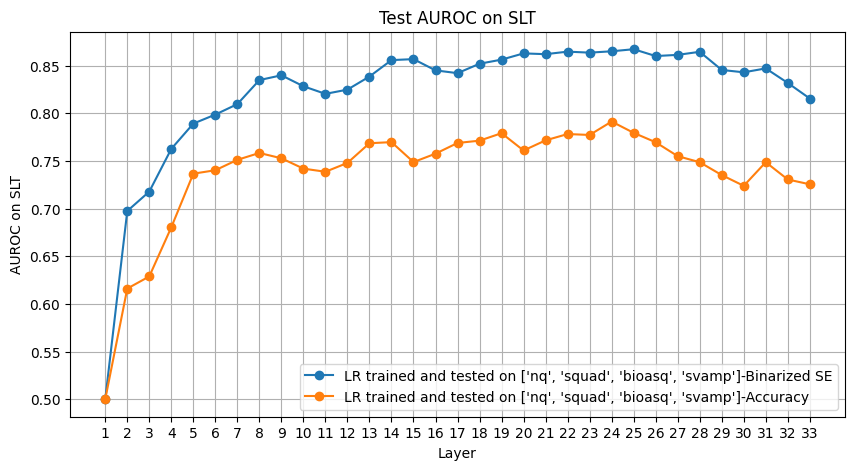

SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s SE and tested on ['nq', 'squad', 'bioasq', 'svamp']'s SE:
	- 0.8673 at layer 25
	- 0.8652 at layer 24
	- 0.8648 at layer 22
	- 0.8646 at layer 28
	- 0.8637 at layer 23
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s Acc and tested on ['nq', 'squad', 'bioasq', 'svamp']'s Acc:
	- 0.7914 at layer 24
	- 0.7796 at layer 25
	- 0.7792 at layer 19
	- 0.7783 at layer 22
	- 0.7774 at layer 23


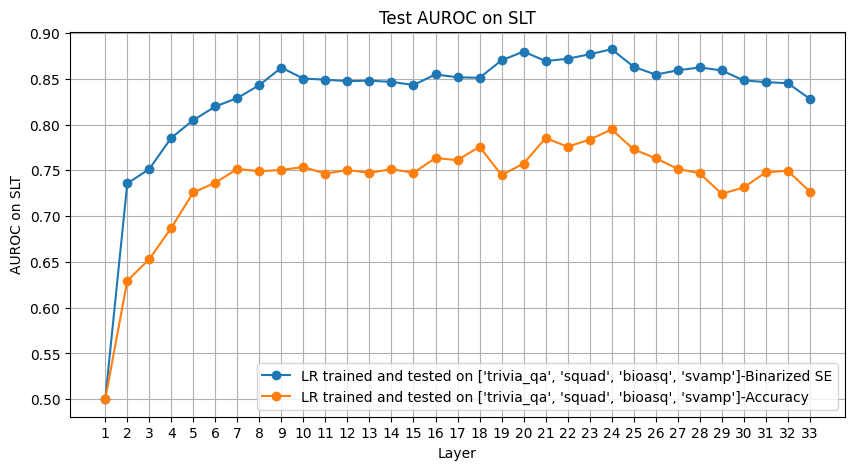

SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SE and tested on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SE:
	- 0.8822 at layer 24
	- 0.8796 at layer 20
	- 0.8767 at layer 23
	- 0.8718 at layer 22
	- 0.8701 at layer 19
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s Acc and tested on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s Acc:
	- 0.7947 at layer 24
	- 0.7852 at layer 21
	- 0.7835 at layer 23
	- 0.7758 at layer 22
	- 0.7757 at layer 18


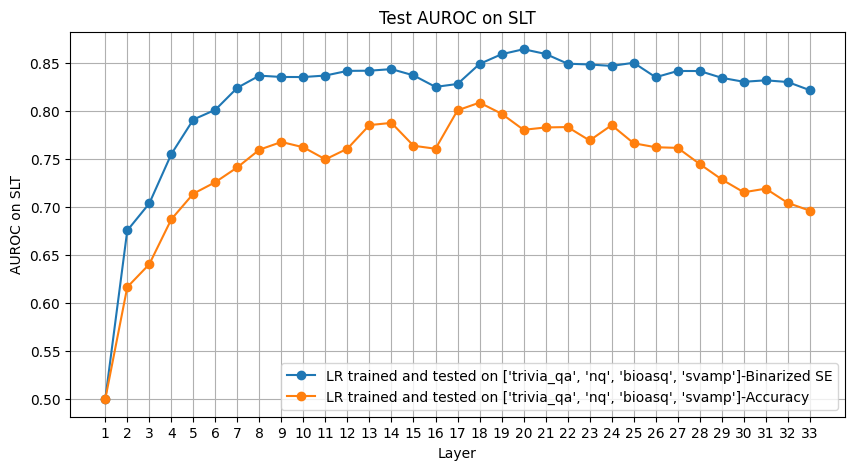

SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SE and tested on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SE:
	- 0.8639 at layer 20
	- 0.8590 at layer 21
	- 0.8587 at layer 19
	- 0.8499 at layer 25
	- 0.8489 at layer 22
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s Acc and tested on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s Acc:
	- 0.8084 at layer 18
	- 0.8004 at layer 17
	- 0.7969 at layer 19
	- 0.7873 at layer 14
	- 0.7851 at layer 13


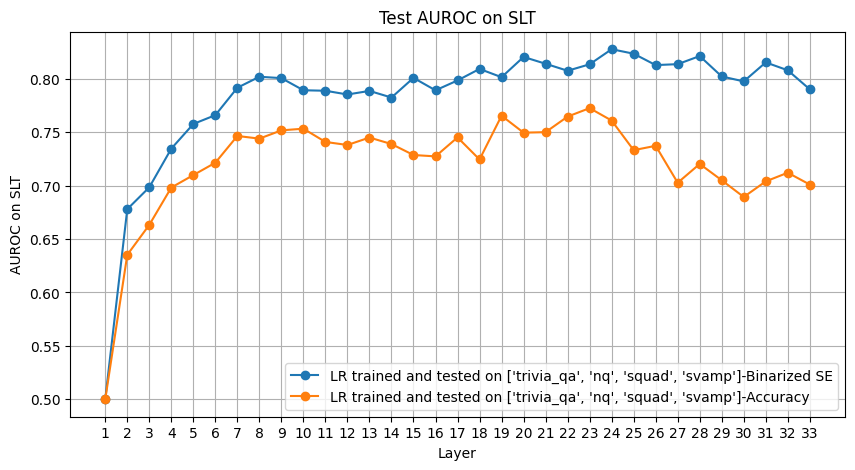

SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s SE and tested on ['trivia_qa', 'nq', 'squad', 'svamp']'s SE:
	- 0.8276 at layer 24
	- 0.8234 at layer 25
	- 0.8212 at layer 28
	- 0.8204 at layer 20
	- 0.8153 at layer 31
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s Acc and tested on ['trivia_qa', 'nq', 'squad', 'svamp']'s Acc:
	- 0.7725 at layer 23
	- 0.7654 at layer 19
	- 0.7646 at layer 22
	- 0.7608 at layer 24
	- 0.7532 at layer 10


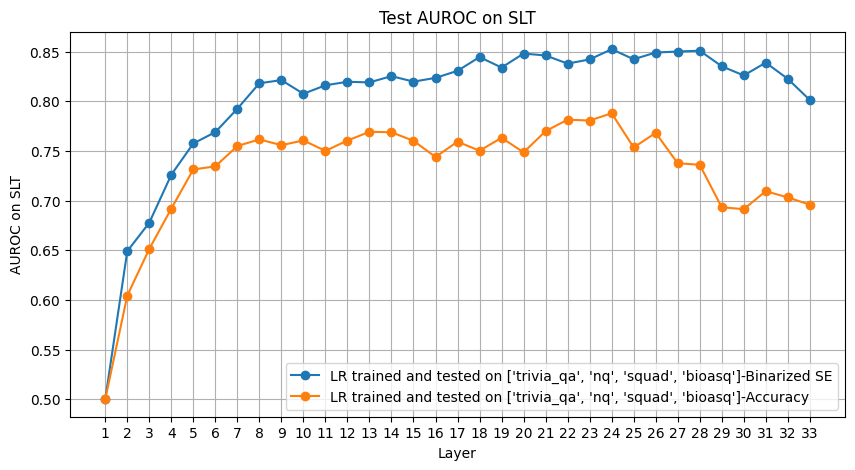

SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s SE and tested on ['trivia_qa', 'nq', 'squad', 'bioasq']'s SE:
	- 0.8524 at layer 24
	- 0.8509 at layer 28
	- 0.8501 at layer 27
	- 0.8490 at layer 26
	- 0.8480 at layer 20
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s Acc and tested on ['trivia_qa', 'nq', 'squad', 'bioasq']'s Acc:
	- 0.7879 at layer 24
	- 0.7814 at layer 22
	- 0.7805 at layer 23
	- 0.7699 at layer 21
	- 0.7692 at layer 13


In [28]:
for D in Ds:
    plot_metrics([D.osb_aucs, D.osa_aucs], [f'LR trained and tested on {D.other_names}-Binarized SE', f'LR trained and tested on {D.other_names}-Accuracy'], f'AUROC on SLT')
    best_metric([D.osb_aucs], token="SLT", train="SE", test="SE", ds=[[D.other_names]*2])
    best_metric([D.osa_aucs], token="SLT", train="Acc", test="Acc", ds=[[D.other_names]*2])

We see the best layers are mostly from layer `12` to `15`.

In [29]:
# Test
def test_n_on_one(D):
    other_ids = D.other_ids
    other_names = D.other_names
    osb_models = D.osb_models
    osa_models = D.osa_models
    
    print(f"Testing on {D.name}'s SE")
    _, _, X_tests, _, _, y_tests = create_Xs_and_ys(D.slt_dataset, D.b_entropy, D.total_size) 
    isb_accs = []
    isb_aucs = []
    
    for k, (X_test, y_test) in enumerate(zip(X_tests, y_tests)):
        # print(f"Testing on {D.name}-SLT-SE {k+1}/{len(X_tests)}")
        model = osb_models[k]
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True, silent=True)
        isb_accs.append(test_acc)
        isb_aucs.append(test_auc)

    D.isb_accs = isb_accs
    D.isb_aucs = isb_aucs
    plot_metrics([D.sb_aucs, D.isb_aucs], [f'LR trained and tested on {D.name}-SE', 
                                                       # f'LR trained and tested on \n{other_names}-SE',
                                                       f'LR trained on {other_names}-SE \n and tested on {D.name}-SE'], 
                 f'AUROC on SLT')
    best_metric([D.sb_aucs], token="SLT", train="SE", test="SE", ds=[[D.name]*2])
    best_metric([D.isb_aucs], token="SLT", train="SE", test="SE", ds=[[other_names, D.name]])

    print(f"\nTesting on {D.name}'s Acc")
    r_acc = 1 - D.accuracies
    _, _, X_tests, _, _, y_tests = create_Xs_and_ys(D.slt_dataset, r_acc, D.total_size) 
    isab_accs = []
    isab_aucs = []
    isaa_accs = []
    isaa_aucs = []

    for k, (X_test, y_test) in enumerate(zip(X_tests, y_tests)):
        # print(f"Testing on {D.name}-SLT-Acc {k+1}/{len(X_tests)}")
        b_model = osb_models[k]
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(b_model, X_test, y_test, binary_cls=True, silent=True)
        isab_accs.append(test_acc)
        isab_aucs.append(test_auc)
        
        a_model = osa_models[k]
        test_loss, test_acc, test_auc = sklearn_evaluate_on_test(a_model, X_test, y_test, binary_cls=True, silent=True)
        isaa_accs.append(test_acc)
        isaa_aucs.append(test_auc)
    
    D.isab_accs = isab_accs
    D.isab_aucs = isab_aucs
    D.isaa_accs = isaa_accs
    D.isaa_aucs = isaa_aucs

    plot_metrics([D.sa_aucs, D.sab_aucs, D.isab_aucs, D.isaa_aucs], 
                 [f'LR trained and tested on {D.name}-Acc', 
                  f'LR trained on {D.name}-SE\n and tested on {D.name}-Acc', 
                  f'LR trained on {other_names}-SE\n and tested on {D.name}-Acc', 
                  f'LR trained on {other_names}-Acc\n and tested on {D.name}-Acc ',
                 ], 
                 f'AUROC on SLT')
    best_metric([D.sa_aucs], token="SLT", train="Acc", test="Acc", ds=[[D.name]*2])
    best_metric([D.sab_aucs], token="SLT", train="SE", test="Acc", ds=[[D.name]*2])
    best_metric([D.isab_aucs], token="SLT", train="SE", test="Acc", ds=[[other_names, D.name]])
    best_metric([D.isaa_aucs], token="SLT", train="Acc", test="Acc", ds=[[other_names, D.name]])

Testing on trivia_qa's SE


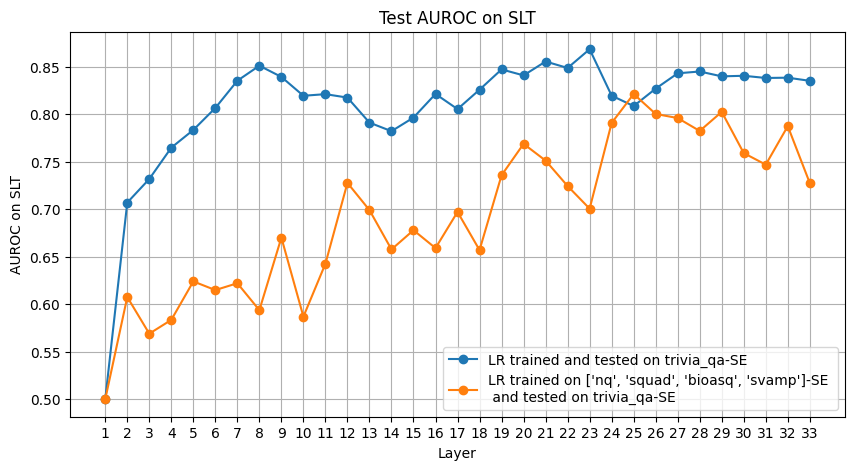

SLT: max AUROC for LR trained on trivia_qa's SE and tested on trivia_qa's SE:
	- 0.8686 at layer 23
	- 0.8556 at layer 21
	- 0.8512 at layer 8
	- 0.8488 at layer 22
	- 0.8473 at layer 19
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s SE and tested on trivia_qa's SE:
	- 0.8215 at layer 25
	- 0.8026 at layer 29
	- 0.8004 at layer 26
	- 0.7961 at layer 27
	- 0.7909 at layer 24

Testing on trivia_qa's Acc


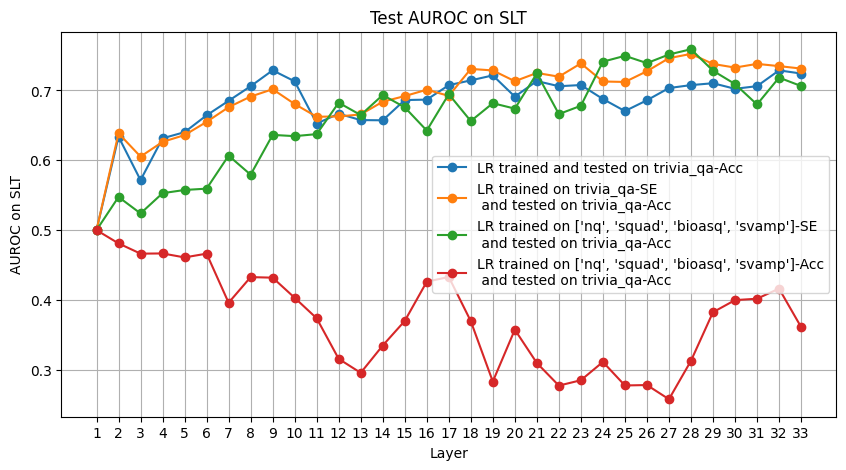

SLT: max AUROC for LR trained on trivia_qa's Acc and tested on trivia_qa's Acc:
	- 0.7289 at layer 9
	- 0.7288 at layer 32
	- 0.7243 at layer 33
	- 0.7216 at layer 19
	- 0.7145 at layer 18
SLT: max AUROC for LR trained on trivia_qa's SE and tested on trivia_qa's Acc:
	- 0.7524 at layer 28
	- 0.7463 at layer 27
	- 0.7388 at layer 23
	- 0.7381 at layer 31
	- 0.7380 at layer 29
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s SE and tested on trivia_qa's Acc:
	- 0.7591 at layer 28
	- 0.7516 at layer 27
	- 0.7497 at layer 25
	- 0.7413 at layer 24
	- 0.7392 at layer 26
SLT: max AUROC for LR trained on ['nq', 'squad', 'bioasq', 'svamp']'s Acc and tested on trivia_qa's Acc:
	- 0.5000 at layer 1
	- 0.4810 at layer 2
	- 0.4666 at layer 4
	- 0.4663 at layer 3
	- 0.4663 at layer 6


In [30]:
# Inspect dataset by dataset
test_n_on_one(D1)

Testing on nq's SE


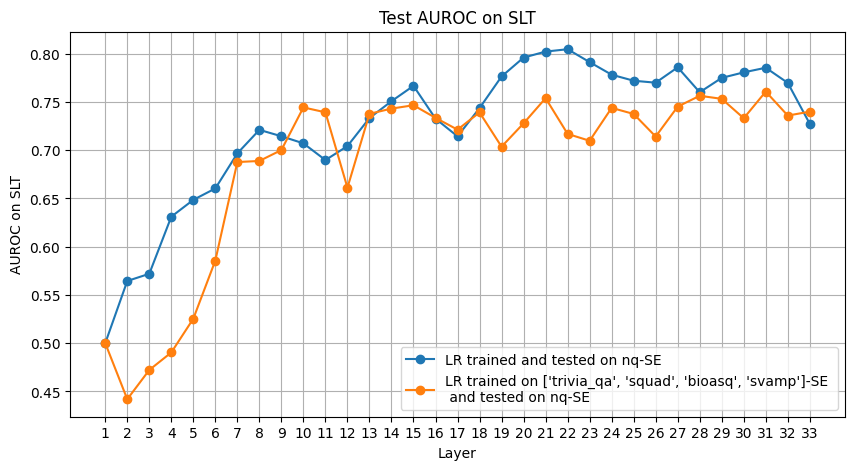

SLT: max AUROC for LR trained on nq's SE and tested on nq's SE:
	- 0.8046 at layer 22
	- 0.8021 at layer 21
	- 0.7959 at layer 20
	- 0.7912 at layer 23
	- 0.7858 at layer 27
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SE and tested on nq's SE:
	- 0.7607 at layer 31
	- 0.7563 at layer 28
	- 0.7539 at layer 21
	- 0.7532 at layer 29
	- 0.7465 at layer 15

Testing on nq's Acc


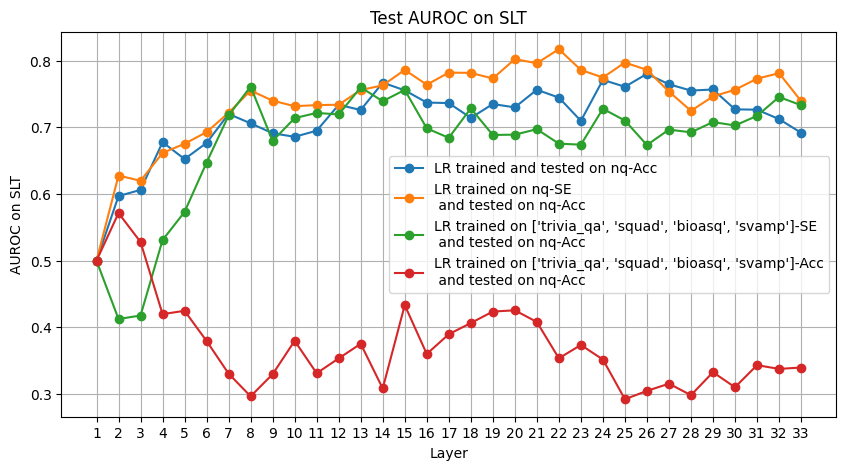

SLT: max AUROC for LR trained on nq's Acc and tested on nq's Acc:
	- 0.7801 at layer 26
	- 0.7711 at layer 24
	- 0.7670 at layer 14
	- 0.7645 at layer 27
	- 0.7608 at layer 25
SLT: max AUROC for LR trained on nq's SE and tested on nq's Acc:
	- 0.8171 at layer 22
	- 0.8022 at layer 20
	- 0.7971 at layer 25
	- 0.7961 at layer 21
	- 0.7861 at layer 15
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s SE and tested on nq's Acc:
	- 0.7610 at layer 8
	- 0.7599 at layer 13
	- 0.7561 at layer 15
	- 0.7455 at layer 32
	- 0.7391 at layer 14
SLT: max AUROC for LR trained on ['trivia_qa', 'squad', 'bioasq', 'svamp']'s Acc and tested on nq's Acc:
	- 0.5714 at layer 2
	- 0.5280 at layer 3
	- 0.5000 at layer 1
	- 0.4334 at layer 15
	- 0.4256 at layer 20


In [31]:
# Inspect dataset by dataset
test_n_on_one(D2)

Testing on bioasq's SE


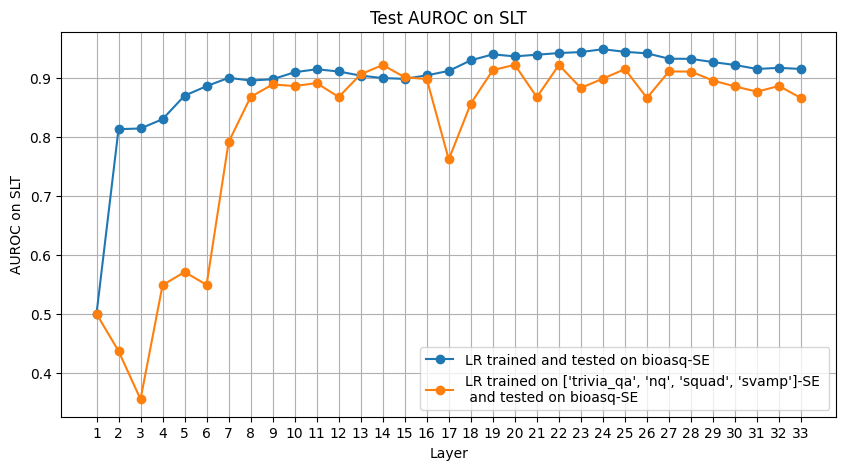

SLT: max AUROC for LR trained on bioasq's SE and tested on bioasq's SE:
	- 0.9485 at layer 24
	- 0.9441 at layer 25
	- 0.9437 at layer 23
	- 0.9420 at layer 22
	- 0.9415 at layer 26
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s SE and tested on bioasq's SE:
	- 0.9221 at layer 20
	- 0.9218 at layer 22
	- 0.9218 at layer 14
	- 0.9148 at layer 25
	- 0.9132 at layer 19

Testing on bioasq's Acc


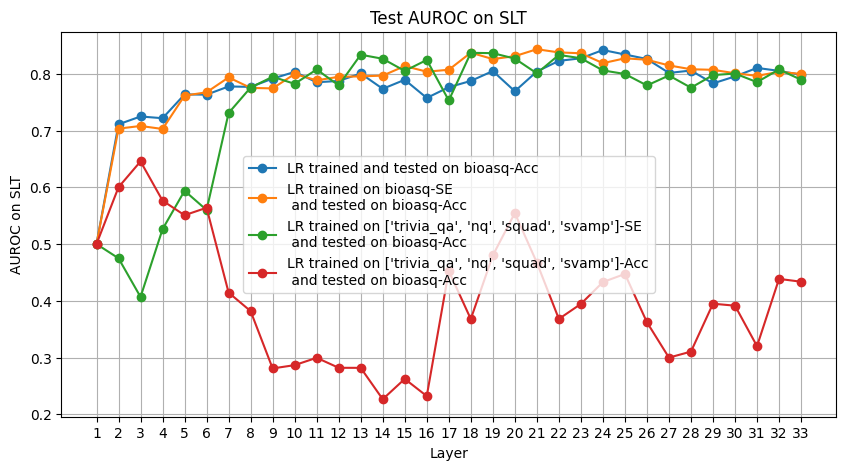

SLT: max AUROC for LR trained on bioasq's Acc and tested on bioasq's Acc:
	- 0.8419 at layer 24
	- 0.8340 at layer 25
	- 0.8273 at layer 23
	- 0.8261 at layer 26
	- 0.8228 at layer 22
SLT: max AUROC for LR trained on bioasq's SE and tested on bioasq's Acc:
	- 0.8433 at layer 21
	- 0.8377 at layer 22
	- 0.8372 at layer 18
	- 0.8362 at layer 23
	- 0.8311 at layer 20
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s SE and tested on bioasq's Acc:
	- 0.8370 at layer 18
	- 0.8364 at layer 19
	- 0.8336 at layer 13
	- 0.8333 at layer 22
	- 0.8274 at layer 23
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'svamp']'s Acc and tested on bioasq's Acc:
	- 0.6457 at layer 3
	- 0.6002 at layer 2
	- 0.5765 at layer 4
	- 0.5640 at layer 6
	- 0.5546 at layer 20


In [32]:
# Inspect dataset by dataset
test_n_on_one(D4)

Testing on squad's SE


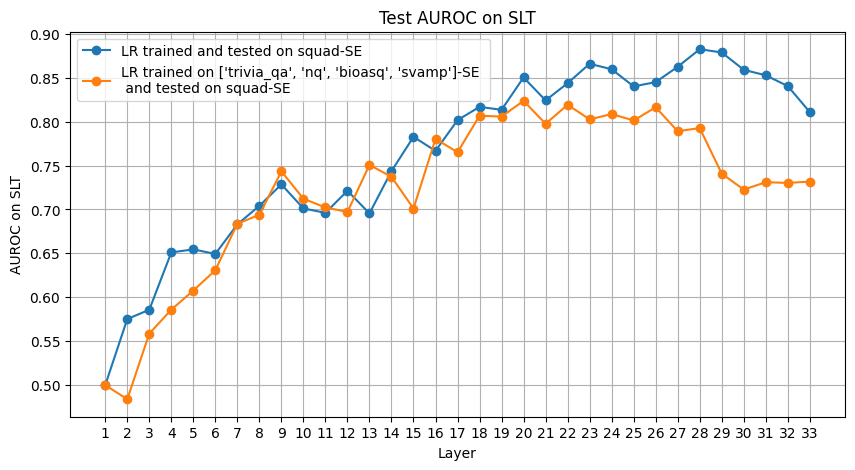

SLT: max AUROC for LR trained on squad's SE and tested on squad's SE:
	- 0.8823 at layer 28
	- 0.8787 at layer 29
	- 0.8658 at layer 23
	- 0.8623 at layer 27
	- 0.8595 at layer 24
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SE and tested on squad's SE:
	- 0.8236 at layer 20
	- 0.8192 at layer 22
	- 0.8163 at layer 26
	- 0.8086 at layer 24
	- 0.8066 at layer 18

Testing on squad's Acc


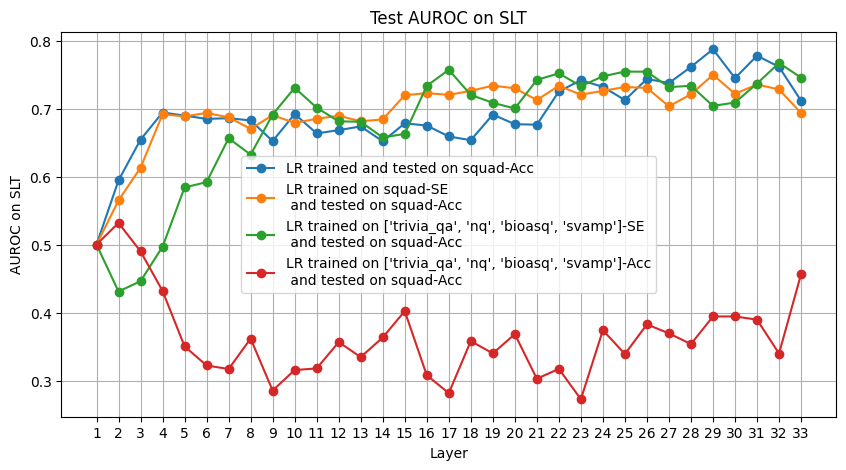

SLT: max AUROC for LR trained on squad's Acc and tested on squad's Acc:
	- 0.7872 at layer 29
	- 0.7777 at layer 31
	- 0.7613 at layer 32
	- 0.7613 at layer 28
	- 0.7447 at layer 30
SLT: max AUROC for LR trained on squad's SE and tested on squad's Acc:
	- 0.7496 at layer 29
	- 0.7354 at layer 31
	- 0.7337 at layer 19
	- 0.7334 at layer 22
	- 0.7317 at layer 25
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s SE and tested on squad's Acc:
	- 0.7670 at layer 32
	- 0.7570 at layer 17
	- 0.7544 at layer 25
	- 0.7541 at layer 26
	- 0.7518 at layer 22
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'bioasq', 'svamp']'s Acc and tested on squad's Acc:
	- 0.5318 at layer 2
	- 0.5000 at layer 1
	- 0.4900 at layer 3
	- 0.4564 at layer 33
	- 0.4318 at layer 4


In [33]:
# Inspect dataset by dataset
test_n_on_one(D3)

Testing on svamp's SE


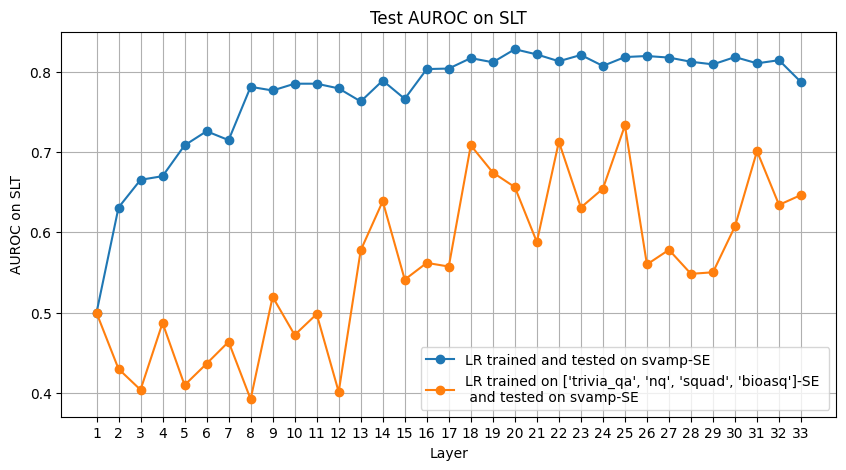

SLT: max AUROC for LR trained on svamp's SE and tested on svamp's SE:
	- 0.8278 at layer 20
	- 0.8213 at layer 21
	- 0.8207 at layer 23
	- 0.8194 at layer 26
	- 0.8181 at layer 30
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s SE and tested on svamp's SE:
	- 0.7329 at layer 25
	- 0.7128 at layer 22
	- 0.7083 at layer 18
	- 0.7011 at layer 31
	- 0.6745 at layer 19

Testing on svamp's Acc


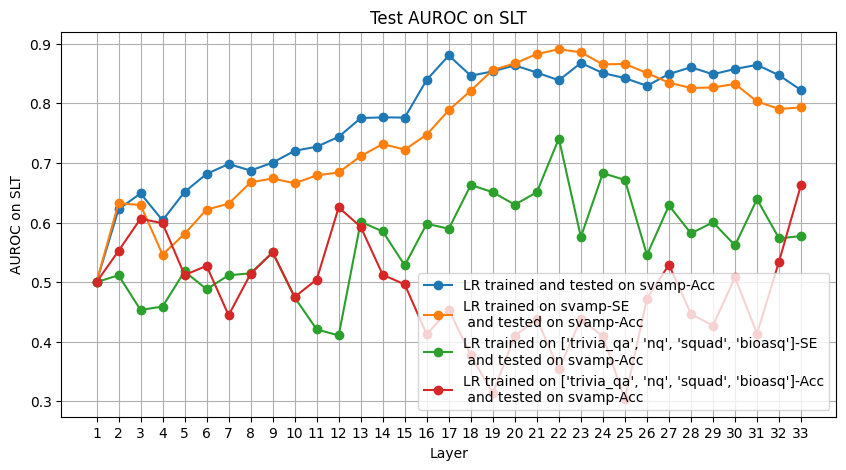

SLT: max AUROC for LR trained on svamp's Acc and tested on svamp's Acc:
	- 0.8804 at layer 17
	- 0.8679 at layer 23
	- 0.8646 at layer 31
	- 0.8638 at layer 20
	- 0.8606 at layer 28
SLT: max AUROC for LR trained on svamp's SE and tested on svamp's Acc:
	- 0.8909 at layer 22
	- 0.8857 at layer 23
	- 0.8828 at layer 21
	- 0.8671 at layer 20
	- 0.8663 at layer 25
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s SE and tested on svamp's Acc:
	- 0.7410 at layer 22
	- 0.6828 at layer 24
	- 0.6715 at layer 25
	- 0.6630 at layer 18
	- 0.6509 at layer 19
SLT: max AUROC for LR trained on ['trivia_qa', 'nq', 'squad', 'bioasq']'s Acc and tested on svamp's Acc:
	- 0.6634 at layer 33
	- 0.6255 at layer 12
	- 0.6065 at layer 3
	- 0.5988 at layer 4
	- 0.5927 at layer 13


In [34]:
# Inspect dataset by dataset
test_n_on_one(D5)

## Generalize probes trained with one dataset's SE to predicting another's SE/Acc
Train probes on one dataset's SE and test it to other dataset's Acc prediction.

In [35]:
# Train on one's SE and test on others' SE/Acc
def test_one_on_n(D):
    other_ids = D.other_ids
    other_names = D.other_names
    sb_models = D.sb_models
    
    print(f"Using probes trained on datasets {D.name.upper()}'s SLT-SE to predict {other_names}'s SLT-SE")
    
    sbo_accs = {}
    sbo_aucs = {}
    
    for id_ in D.other_ids:
        D_id = Ds[id_]
        print(f"Testing on {D_id.name.upper()}'s SLT-SE")
        _, _, X_tests, _, _, y_tests = create_Xs_and_ys(D_id.slt_dataset, D_id.b_entropy, D_id.total_size)
        id_accs = []
        id_aucs = []
        for i, (X_test, y_test) in enumerate(zip(X_tests, y_tests)):
            model = sb_models[i]
            test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True, silent=True)
            id_accs.append(test_acc)
            id_aucs.append(test_auc)

        sbo_accs[D_id.name] = id_accs
        sbo_aucs[D_id.name] = id_aucs

        plot_metrics([D_id.sb_aucs, D_id.isb_aucs, id_aucs], [f'LR trained and tested on {D_id.name}-SE',
                                                              f'LR trained on {D_id.other_names}-SE,\n tested on {D_id.name}-SE',
                                                              f'LR trained on {D.name}-SE, tested on {D_id.name}-SE'], 
                     f'AUROC on SLT')
        best_metric([D_id.sb_aucs], token="SLT", train="SE", test="SE", ds=[[D_id.name]*2])
        best_metric([D_id.isb_aucs], token="SLT", train="SE", test="SE", ds=[[D_id.other_names, D_id.name]])
        best_metric([id_aucs], token="SLT", train="SE", test="SE", ds=[[D.name, D_id.name]])
        

    D.sbo_accs = sbo_accs
    D.sbo_aucs = sbo_aucs

    print(f"\n\nUsing probes trained on datasets {D.name.upper()}'s SLT-SE to predict {other_names}'s SLT-Acc")
    
    sao_accs = {}
    sao_aucs = {}
    
    for id_ in D.other_ids:
        D_id = Ds[id_]
        print(f"Testing on {D_id.name.upper()}'s SLT-Acc")
        _, _, X_tests, _, _, y_tests = create_Xs_and_ys(D_id.slt_dataset, 1-D_id.accuracies, D_id.total_size)
        id_accs = []
        id_aucs = []
        for i, (X_test, y_test) in enumerate(zip(X_tests, y_tests)):
            model = sb_models[i]
            test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True, silent=True)
            id_accs.append(test_acc)
            id_aucs.append(test_auc)

        sao_accs[D_id.name] = id_accs
        sao_aucs[D_id.name] = id_aucs

        plot_metrics([D_id.sa_aucs, D_id.isab_aucs, id_aucs, D_id.isaa_aucs], [f'LR trained and tested on {D_id.name}-Acc',
                                                                               f'LR trained on {D_id.other_names}-SE,\n tested on {D_id.name}-Acc',
                                                                               f'LR trained on {D.name}-SE,\n tested on {D_id.name}-Acc',
                                                                                f'LR trained on {D_id.other_names}-Acc,\n tested on {D_id.name}-Acc'], 
                     f'AUROC on SLT')

        best_metric([D_id.sa_aucs], token="SLT", train="Acc", test="Acc", ds=[[D_id.name]*2])
        best_metric([D_id.isab_aucs], token="SLT", train="SE", test="Acc", ds=[[D_id.other_names, D_id.name]])
        best_metric([id_aucs], token="SLT", train="SE", test="Acc", ds=[[D.name, D_id.name]])
        best_metric([D_id.isaa_aucs], token="SLT", train="Acc", test="Acc", ds=[[D_id.other_names, D_id.name]])
    
    D.sao_accs = sao_accs
    D.sao_aucs = sao_aucs

In [ ]:
test_one_on_n(D1)

In [ ]:
test_one_on_n(D2)

In [ ]:
test_one_on_n(D3)

In [ ]:
test_one_on_n(D4)

In [ ]:
test_one_on_n(D5)

SVAMP dataset is really weak in generalization.

## Save dataset metrics

In [41]:
# save dataset fields to pickle
import pickle
from datetime import datetime

Ds_save = ()
excl_attrs = ['tbg_dataset', 'slt_dataset', 'entropy', 'ca_entropy', 'accuracies', 'b_entropy'] 

for D in Ds:
    D_save = {key: value for key, value in vars(D).items() if key not in excl_attrs}
    Ds_save += (D_save,)

path = "~/Downloads/oatml/semantic_uncertainty/latent_probe_notebooks/phi-3-3.8b-notebooks/metrics"
full_path = os.path.expanduser(path)
os.makedirs(full_path, exist_ok=True)
time_now = datetime.now().strftime("%Y%m%d-%H%M%S")

f = open(f'{full_path}/{time_now}_{"_".join([D.name + "-" + str(D.total_size) for D in Ds])}.pkl', 'wb')
pickle.dump(Ds_save, f)
f.close()